# Imports

In [ ]:
import numpy as np
import pandas as pd
import os
import re
import matplotlib.pyplot as plt
import seaborn as sns
import ast
from scipy.stats import shapiro, levene, ttest_ind, mannwhitneyu, pearsonr, ttest_1samp,  f_oneway, kruskal
import scipy.stats as stats
import ast
from itertools import combinations
from statsmodels.stats.multicomp import pairwise_tukeyhsd
import scikit_posthocs as sp

# General variables

 ## Filenames

In [ ]:
# Define the pattern of filenames

GameTheoretic_filename_pattern_DQN =  re.compile(r"results_(?P<simulation_index>\d{3})_(?P<episodes>\d+)_DQN_"
                                                r"(?P<emotion>[^_]+)_(?P<see_emotions>[^_]+)_"
                                                r"(?P<alpha>[\d.]+)_(?P<beta>[\d.]+)_(?P<smoothing>[^_]+)_(?P<threshold>[\d.]+)_(?P<rounder>[\d.]+)_"
                                                r"(?P<learning_rate>[\d.]+)_(?P<gamma>[\d.]+)_(?P<epsilon>[\d.]+)_(?P<epsilon_decay>[\d.]+)_(?P<epsilon_min>[\d.]+)_"
                                                r"(?P<batch_size>[\d.]+)_(?P<hidden_size>[\d.]+)_(?P<update_target_every>[\d.]+)_"
                                                r"(?P<random_suffix>\d{6})_(?P<suffix>[a-zA-Z]+_[a-zA-Z]+)\.csv"
)

GameTheoretic_filename_pattern_QL = re.compile(r"results_(?P<simulation_index>\d{3})_(?P<episodes>\d+)_QLearning_"
                                              r"(?P<emotion>[^_]+)_(?P<see_emotions>[^_]+)_"
                                              r"(?P<alpha>[\d.]+)_(?P<beta>[\d.]+)_(?P<smoothing>[^_]+)_(?P<threshold>[\d.]+)_(?P<rounder>[\d.]+)_"
                                              r"(?P<learning_rate>[\d.]+)_(?P<gamma>[\d.]+)_(?P<epsilon>[\d.]+)_(?P<epsilon_decay>[\d.]+)_(?P<epsilon_min>[\d.]+)_"
                                              r"(?P<random_suffix>\d{6})_(?P<suffix>[a-zA-Z]+_[a-zA-Z]+)\.csv"
)


Maze2D_filename_order_QL = re.compile(
    r"maze2d_results_(?P<simulation_index>\d{3})_(?P<episodes>\d+)_QLearning_"
    r"(?P<emotion>[^_]+)_(?P<see_emotions>[^_]+)_"
    r"(?P<alpha>[\d.]+)_(?P<beta>[\d.]+)_(?P<smoothing>[^_]+)_(?P<threshold>[\d.]+)_(?P<rounder>[\d.]+)_"
    r"(?P<learning_rate>[\d.]+)_(?P<gamma>[\d.]+)_(?P<epsilon>[\d.]+)_(?P<epsilon_decay>[\d.]+)_(?P<epsilon_min>[\d.]+)_"
    r"(?P<random_suffix>\d{6})_(?P<suffix>[a-zA-Z]+_[a-zA-Z]+)\.csv"
)

Maze2D_filename_order_DQN = re.compile(
    r"maze2d_results_(?P<simulation_index>\d{3})_(?P<episodes>\d+)_DQN_"
    r"(?P<emotion>[^_]+)_(?P<see_emotions>[^_]+)_"
    r"(?P<alpha>[\d.]+)_(?P<beta>[\d.]+)_(?P<smoothing>[^_]+)_(?P<threshold>[\d.]+)_(?P<rounder>[\d.]+)_"
    r"(?P<learning_rate>[\d.]+)_(?P<gamma>[\d.]+)_(?P<epsilon>[\d.]+)_(?P<epsilon_decay>[\d.]+)_(?P<epsilon_min>[\d.]+)_"
    r"(?P<batch_size>[\d.]+)_(?P<hidden_size>[\d.]+)_(?P<update_target_every>[\d.]+)_"
    r"(?P<random_suffix>\d{6})_(?P<suffix>[a-zA-Z]+_[a-zA-Z]+)\.csv"
)

FILENAME_PATTERNS = [
    GameTheoretic_filename_pattern_DQN,
    GameTheoretic_filename_pattern_QL,
    Maze2D_filename_order_DQN,
    Maze2D_filename_order_QL
]

FILENAME_PATTERNS_PAIR = [
    ("Gametheoretic", GameTheoretic_filename_pattern_DQN),
    ("Gametheoretic", GameTheoretic_filename_pattern_QL),
    ("maze2d", Maze2D_filename_order_DQN),
    ("maze2d", Maze2D_filename_order_QL)
]

# Claude test

# Functions

In [ ]:
# ============================================================================
# UNIFIED STATISTICAL ANALYSIS AND VISUALIZATION CLASS
# Publication-Ready, Modular, Elegant
# ============================================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from statsmodels.formula.api import ols
from statsmodels.stats.anova import anova_lm
from statsmodels.stats.multicomp import pairwise_tukeyhsd
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import LabelEncoder
import warnings

warnings.filterwarnings('ignore')


class StatisticalAnalyzer:
    """
    Unified class for statistical analysis and publication-ready visualization.
    
    Supports:
    - Categorical analysis (ANOVA, Kruskal-Wallis, boxplots, violin plots)
    - Continuous analysis (Linear regression, scatter plots)
    - Interaction analysis and plots
    - Flexible dependent and independent variables
    - Publication-quality figures ready for posters
    
    Parameters:
    -----------
    dataframe : pd.DataFrame
        Input data containing all variables
    dependent_var : str or list
        Variable(s) to analyze (y-axis)
    independent_vars : str or list
        Variable(s) used as predictors/grouping (x-axis)
    analysis_type : str
        'categorical' (ANOVA/boxplot) or 'continuous' (regression/scatter)
    categorical_vars : list, optional
        List of variables to treat as categorical
    style : str
        'poster' (large, bold, publication-ready) or 'paper' (smaller)
    palette : str
        Color palette name (e.g., 'husl', 'Set2', 'deep')
    """
    
    def __init__(
        self,
        dataframe,
        dependent_var,
        independent_vars,
        analysis_type='categorical',
        categorical_vars=None,
        style='poster',
        palette='husl',
        save_graph=False
    ):
        self.df = dataframe.copy()
        self.dependent_var = dependent_var if isinstance(dependent_var, list) else [dependent_var]
        self.independent_vars = independent_vars if isinstance(independent_vars, list) else [independent_vars]
        self.analysis_type = analysis_type.lower()
        self.categorical_vars = categorical_vars or []
        self.style = style
        self.palette = palette
        self.save_graph = save_graph
        
        # Results storage
        self.results = {}
        self.figures = {}
        
        # Configure style
        self._configure_style()
        
        # Validate data
        self._validate_data()
    
    def _validate_data(self):
        """Validate input data"""
        all_vars = self.dependent_var + self.independent_vars
        missing = [v for v in all_vars if v not in self.df.columns]
        if missing:
            raise ValueError(f"Missing columns: {missing}")
        
        # Convert categorical variables
        for var in self.categorical_vars:
            if var in self.df.columns:
                self.df[var] = self.df[var].astype('category')
    
    def _configure_style(self):
        """Configure matplotlib and seaborn styles"""
        sns.set_style("whitegrid")
        
        if self.style == 'poster':
            plt.rcParams['figure.figsize'] = (16, 10)
            plt.rcParams['font.size'] = 14
            plt.rcParams['axes.labelsize'] = 16
            plt.rcParams['axes.titlesize'] = 18
            plt.rcParams['xtick.labelsize'] = 12
            plt.rcParams['ytick.labelsize'] = 12
            plt.rcParams['legend.fontsize'] = 12
            plt.rcParams['lines.linewidth'] = 2.5
            plt.rcParams['lines.markersize'] = 8
            plt.rcParams['axes.linewidth'] = 1.5
        else:  # paper
            plt.rcParams['figure.figsize'] = (12, 7)
            plt.rcParams['font.size'] = 11
            plt.rcParams['axes.labelsize'] = 12
            plt.rcParams['axes.titlesize'] = 13
    
    def run_analysis(self, verbose=True):
        """Execute complete analysis"""
        if verbose:
            print(f"\n{'='*80}")
            print(f"STATISTICAL ANALYSIS")
            print(f"Type: {self.analysis_type.upper()}")
            print(f"Dependent: {self.dependent_var}")
            print(f"Independent: {self.independent_vars}")
            print(f"{'='*80}\n")
        
        if self.analysis_type == 'categorical':
            return self._categorical_analysis(verbose)
        elif self.analysis_type == 'continuous':
            return self._continuous_analysis(verbose)
        else:
            raise ValueError(f"Unknown analysis_type: {self.analysis_type}")
    
    # ========================================================================
    # CATEGORICAL ANALYSIS (ANOVA, Kruskal-Wallis, etc.)
    # ========================================================================
    
    def _categorical_analysis(self, verbose=True):
        """Perform categorical analysis (groups comparison)"""
        for dep_var in self.dependent_var:
            self.results[dep_var] = {}
            
            if verbose:
                print(f"\n{'─'*80}")
                print(f"Variable: {dep_var}")
                print(f"{'─'*80}\n")
            
            # Descriptive statistics
            self._descriptive_stats(dep_var, verbose)
            
            # Test assumptions
            assumptions_ok = self._test_assumptions(dep_var, verbose)
            
            # Run ANOVA or Kruskal-Wallis
            self._run_anova(dep_var, assumptions_ok, verbose)
            
            # Post-hoc tests
            self._post_hoc_tests(dep_var, verbose)
            
            # Create visualizations
            self._create_categorical_plots(dep_var)
        
        return self.results
    
    def _descriptive_stats(self, dep_var, verbose=True):
        """Calculate and display descriptive statistics"""
        if verbose:
            print("📊 DESCRIPTIVE STATISTICS")
            print("─" * 80)
        
        # Group by all independent variables
        grouped = self.df.groupby(self.independent_vars)[dep_var].agg([
            'count', 'mean', 'std', 'median', 'min', 'max', 'sem'
        ]).round(4)
        
        if verbose:
            print(grouped)
            print()
        
        self.results[dep_var]['descriptive'] = grouped
    
    def _test_assumptions(self, dep_var, verbose=True):
        """Test normality and homogeneity of variance"""
        if verbose:
            print("✓ ASSUMPTIONS TESTING")
            print("─" * 80)
        
        # Normality test (Shapiro-Wilk)
        if verbose:
            print("\nNormality (Shapiro-Wilk, p > 0.05 = normal):")
        
        normal_count = 0
        for group_keys, group_data in self.df.groupby(self.independent_vars):
            if len(group_data) >= 3:
                stat, p_val = stats.shapiro(group_data[dep_var])
                is_normal = "✓" if p_val > 0.05 else "✗"
                if verbose:
                    group_str = " × ".join(str(k) for k in (group_keys if isinstance(group_keys, tuple) else [group_keys]))
                    print(f"  {group_str:30s}: W={stat:.3f}, p={p_val:.4f} {is_normal}")
                if p_val > 0.05:
                    normal_count += 1
        
        n_groups = len(self.df.groupby(self.independent_vars))
        if verbose:
            print(f"→ {normal_count}/{n_groups} groups normal\n")
        
        # Levene's test (homogeneity)
        groups = [group[dep_var].values for _, group in self.df.groupby(self.independent_vars)]
        stat, p_val = stats.levene(*groups)
        is_homogeneous = p_val > 0.05
        
        if verbose:
            result_str = "✓ Homogeneous" if is_homogeneous else "✗ Non-homogeneous"
            print(f"Levene's test: F={stat:.3f}, p={p_val:.4f} {result_str}\n")
        
        self.results[dep_var]['assumptions'] = {
            'normality_count': normal_count,
            'total_groups': n_groups,
            'homogeneous': is_homogeneous,
            'levene_p': p_val
        }
        
        return normal_count >= (n_groups / 2) and is_homogeneous
    
    def _run_anova(self, dep_var, assumptions_ok, verbose=True):
        """Run ANOVA or Kruskal-Wallis"""
        if verbose:
            print("\n📈 STATISTICAL TEST")
            print("─" * 80)
        
        # Build formula
        formula = f"{dep_var} ~ {' + '.join([f'C({var})' for var in self.independent_vars])}"
        if len(self.independent_vars) > 1:
            formula += f" + {' * '.join([f'C({var})' for var in self.independent_vars])}"
        
        if assumptions_ok or len(self.df) < 100:
            # ANOVA
            model = ols(formula, data=self.df).fit()
            aov_table = anova_lm(model, typ=2)
            
            if verbose:
                print(f"ANOVA (Type II):\n")
                print(aov_table)
            
            self.results[dep_var]['model'] = model
            self.results[dep_var]['anova_table'] = aov_table
            self.results[dep_var]['test_used'] = 'ANOVA'
            
            # Print summary
            if verbose:
                print("\n📌 EFFECT SUMMARY:")
                print("─" * 80)
                for idx in aov_table.index[:-1]:
                    f_val = aov_table.loc[idx, 'F']
                    p_val = aov_table.loc[idx, 'PR(>F)']
                    sig = "***" if p_val < 0.001 else "**" if p_val < 0.01 else "*" if p_val < 0.05 else "ns"
                    effect_name = idx.replace("C(", "").replace(")", "")
                    print(f"{effect_name:40s}: F={f_val:7.3f}, p={p_val:.4f} {sig}")
                
                # Effect sizes (eta-squared)
                print("\n📏 EFFECT SIZES (η²):")
                print("─" * 80)
                ss_total = aov_table['sum_sq'].sum()
                for idx in aov_table.index[:-1]:
                    ss = aov_table.loc[idx, 'sum_sq']
                    eta_sq = ss / ss_total
                    effect = "Negligible" if eta_sq < 0.01 else "Small" if eta_sq < 0.06 else "Medium" if eta_sq < 0.14 else "Large"
                    effect_name = idx.replace("C(", "").replace(")", "")
                    print(f"{effect_name:40s}: η² = {eta_sq:.4f} ({effect})")
        else:
            # Kruskal-Wallis (non-parametric)
            if verbose:
                print(f"Using Kruskal-Wallis (non-parametric)\n")
            
            groups = [group[dep_var].values for _, group in self.df.groupby(self.independent_vars)]
            stat, p_val = stats.kruskal(*groups)
            
            if verbose:
                print(f"H-statistic = {stat:.3f}, p-value = {p_val:.4f}\n")
            
            self.results[dep_var]['kruskal_stat'] = stat
            self.results[dep_var]['kruskal_p'] = p_val
            self.results[dep_var]['test_used'] = 'Kruskal-Wallis'
    
    def _post_hoc_tests(self, dep_var, verbose=True):
        """Perform post-hoc tests (Tukey HSD)"""
        if len(self.df.groupby(self.independent_vars)) > 2:
            if verbose:
                print("\n🔍 POST-HOC TESTS (Tukey HSD)")
                print("─" * 80 + "\n")
            
            # Create group labels
            self.df['_group'] = self.df[self.independent_vars].astype(str).agg(' × '.join, axis=1)
            
            tukey = pairwise_tukeyhsd(
                endog=self.df[dep_var],
                groups=self.df['_group'],
                alpha=0.05
            )
            
            if verbose:
                print(tukey)
            
            self.results[dep_var]['tukey'] = tukey
    
    def _create_categorical_plots(self, dep_var):
        """Create all categorical plots"""
        # Boxplot
        self._plot_boxplot(dep_var)
        
        # Violin plot
        self._plot_violin(dep_var)
        
        # Strip plot (individual points)
        self._plot_stripplot(dep_var)
        
        # Density plot
        self._plot_density(dep_var)
        
        # Interaction plot (if 2+ independent vars)
        if len(self.independent_vars) > 1:
            self._plot_interaction(dep_var)
    
    def _plot_boxplot(self, dep_var):
        """Create publication-ready boxplot"""
        if len(self.independent_vars) == 1:
            fig, ax = plt.subplots(figsize=(12, 7))
            sns.boxplot(
                data=self.df,
                x=self.independent_vars[0],
                y=dep_var,
                palette=self.palette,
                ax=ax,
                width=0.6,
                linewidth=2
            )
            ax.set_xlabel(self.independent_vars[0], fontsize=16, fontweight='bold')
        else:
            fig, ax = plt.subplots(figsize=(14, 8))
            sns.boxplot(
                data=self.df,
                x=self.independent_vars[0],
                y=dep_var,
                hue=self.independent_vars[1],
                palette=self.palette,
                ax=ax,
                width=0.7,
                linewidth=2
            )
            ax.set_xlabel(self.independent_vars[0], fontsize=16, fontweight='bold')
            ax.legend(title=self.independent_vars[1], fontsize=12, title_fontsize=13)
        
        ax.set_ylabel(dep_var, fontsize=16, fontweight='bold')
        ax.set_title(f"{dep_var} Distribution by Groups", fontsize=18, fontweight='bold', pad=20)
        ax.grid(True, alpha=0.3, axis='y')
        
        plt.tight_layout()
        if self.save_graph:
            fig.savefig(f'boxplot_{dep_var}.png', dpi=300, bbox_inches='tight')
        self.figures[f'boxplot_{dep_var}'] = fig
        plt.show()
    
    def _plot_violin(self, dep_var):
        """Create publication-ready violin plot"""
        if len(self.independent_vars) == 1:
            fig, ax = plt.subplots(figsize=(12, 7))
            sns.violinplot(
                data=self.df,
                x=self.independent_vars[0],
                y=dep_var,
                palette=self.palette,
                ax=ax,
                inner='quartile',
                linewidth=2
            )
            ax.set_xlabel(self.independent_vars[0], fontsize=16, fontweight='bold')
        else:
            fig, ax = plt.subplots(figsize=(14, 8))
            sns.violinplot(
                data=self.df,
                x=self.independent_vars[0],
                y=dep_var,
                hue=self.independent_vars[1],
                palette=self.palette,
                ax=ax,
                inner='quartile',
                linewidth=2
            )
            ax.set_xlabel(self.independent_vars[0], fontsize=16, fontweight='bold')
            ax.legend(title=self.independent_vars[1], fontsize=12, title_fontsize=13)
        
        ax.set_ylabel(dep_var, fontsize=16, fontweight='bold')
        ax.set_title(f"{dep_var} Distribution (Violin Plot)", fontsize=18, fontweight='bold', pad=20)
        ax.grid(True, alpha=0.3, axis='y')
        
        plt.tight_layout()
        if self.save_graph:
            fig.savefig(f'violin_{dep_var}.png', dpi=300, bbox_inches='tight')
        self.figures[f'violin_{dep_var}'] = fig
        plt.show()
    
    def _plot_stripplot(self, dep_var):
        """Create stripplot with jitter and overlaid boxplot"""
        if len(self.independent_vars) == 1:
            fig, ax = plt.subplots(figsize=(12, 7))
            
            # Box plot
            sns.boxplot(
                data=self.df,
                x=self.independent_vars[0],
                y=dep_var,
                palette=self.palette,
                ax=ax,
                width=0.5,
                linewidth=2,
                showcaps=True,
                boxprops={'alpha': 0.7}
            )
            
            # Strip plot
            sns.stripplot(
                data=self.df,
                x=self.independent_vars[0],
                y=dep_var,
                color='black',
                alpha=0.4,
                size=6,
                jitter=True,
                ax=ax
            )
            
            ax.set_xlabel(self.independent_vars[0], fontsize=16, fontweight='bold')
        else:
            fig, ax = plt.subplots(figsize=(14, 8))
            
            sns.boxplot(
                data=self.df,
                x=self.independent_vars[0],
                y=dep_var,
                hue=self.independent_vars[1],
                palette=self.palette,
                ax=ax,
                width=0.6,
                linewidth=2,
                showcaps=True,
                boxprops={'alpha': 0.7}
            )
            
            sns.stripplot(
                data=self.df,
                x=self.independent_vars[0],
                y=dep_var,
                hue=self.independent_vars[1],
                color='black',
                alpha=0.3,
                size=5,
                jitter=True,
                ax=ax,
                legend=False
            )
            
            ax.set_xlabel(self.independent_vars[0], fontsize=16, fontweight='bold')
            ax.legend(title=self.independent_vars[1], fontsize=12, title_fontsize=13)
        
        ax.set_ylabel(dep_var, fontsize=16, fontweight='bold')
        ax.set_title(f"{dep_var} - Individual Data Points", fontsize=18, fontweight='bold', pad=20)
        ax.grid(True, alpha=0.3, axis='y')
        
        plt.tight_layout()
        if self.save_graph:
            fig.savefig(f'stripplot_{dep_var}.png', dpi=300, bbox_inches='tight')
        self.figures[f'stripplot_{dep_var}'] = fig
        plt.show()
    
    def _plot_density(self, dep_var):
        """Create density plot by groups"""
        fig, ax = plt.subplots(figsize=(14, 8))
        
        # Plot density for each group
        colors = sns.color_palette(self.palette, n_colors=len(self.df.groupby(self.independent_vars)))
        
        for (group_key, group_data), color in zip(
            self.df.groupby(self.independent_vars),
            colors
        ):
            label = " × ".join(str(k) for k in (group_key if isinstance(group_key, tuple) else [group_key]))
            group_data[dep_var].plot(
                kind='density',
                ax=ax,
                label=label,
                color=color,
                linewidth=2.5,
                alpha=0.7
            )
        
        ax.set_xlabel(dep_var, fontsize=16, fontweight='bold')
        ax.set_ylabel('Density', fontsize=16, fontweight='bold')
        ax.set_title(f"{dep_var} - Density Distribution", fontsize=18, fontweight='bold', pad=20)
        ax.legend(fontsize=12, title_fontsize=13)
        ax.grid(True, alpha=0.3)
        
        plt.tight_layout()
        if self.save_graph:
            fig.savefig(f'density_{dep_var}.png', dpi=300, bbox_inches='tight')
        self.figures[f'density_{dep_var}'] = fig
        plt.show()
    
    def _plot_interaction(self, dep_var):
        """Create interaction plot"""
        fig, ax = plt.subplots(figsize=(14, 8))
        
        colors = sns.color_palette(self.palette, n_colors=len(self.df[self.independent_vars[1]].unique()))
        
        for color, val2 in zip(colors, sorted(self.df[self.independent_vars[1]].unique())):
            subset = self.df[self.df[self.independent_vars[1]] == val2]
            means = subset.groupby(self.independent_vars[0])[dep_var].mean()
            sem = subset.groupby(self.independent_vars[0])[dep_var].sem()
            
            ax.errorbar(
                range(len(means)),
                means.values,
                yerr=sem.values,
                marker='o',
                linewidth=2.5,
                markersize=10,
                capsize=8,
                label=f"{self.independent_vars[1]} = {val2}",
                color=color,
                alpha=0.8
            )
        
        ax.set_xticks(range(len(means)))
        ax.set_xticklabels(means.index, fontsize=12)
        ax.set_xlabel(self.independent_vars[0], fontsize=16, fontweight='bold')
        ax.set_ylabel(f"{dep_var} (mean ± SEM)", fontsize=16, fontweight='bold')
        ax.set_title(f"Interaction: {self.independent_vars[0]} × {self.independent_vars[1]}", 
                    fontsize=18, fontweight='bold', pad=20)
        ax.legend(fontsize=12, title_fontsize=13, loc='best')
        ax.grid(True, alpha=0.3, axis='y')
        
        plt.tight_layout()
        if self.save_graph:
            fig.savefig(f'interaction_{dep_var}.png', dpi=300, bbox_inches='tight')
        self.figures[f'interaction_{dep_var}'] = fig
        plt.show()
    
    # ========================================================================
    # CONTINUOUS ANALYSIS (Regression, Correlation)
    # ========================================================================
    
    def _continuous_analysis(self, verbose=True):
        """Perform continuous analysis (regression)"""
        for dep_var in self.dependent_var:
            self.results[dep_var] = {}
            
            if verbose:
                print(f"\n{'─'*80}")
                print(f"Variable: {dep_var}")
                print(f"{'─'*80}\n")
            
            # Descriptive statistics
            self._descriptive_stats_continuous(dep_var, verbose)
            
            # Run regression
            self._run_regression(dep_var, verbose)
            
            # Create visualizations
            self._create_continuous_plots(dep_var)
        
        return self.results
    
    def _descriptive_stats_continuous(self, dep_var, verbose=True):
        """Descriptive stats for continuous analysis"""
        if verbose:
            print("📊 DESCRIPTIVE STATISTICS")
            print("─" * 80)
            print(self.df[[dep_var] + self.independent_vars].describe().round(4))
            print()
        
        # Correlations
        if verbose:
            print("🔗 CORRELATIONS")
            print("─" * 80)
            for ind_var in self.independent_vars:
                if pd.api.types.is_numeric_dtype(self.df[ind_var]):
                    corr, p_val = stats.pearsonr(self.df[dep_var], self.df[ind_var])
                    sig = "***" if p_val < 0.001 else "**" if p_val < 0.01 else "*" if p_val < 0.05 else "ns"
                    print(f"{ind_var:30s}: r = {corr:+.4f}, p = {p_val:.4f} {sig}")
            print()
    
    def _run_regression(self, dep_var, verbose=True):
        """Fit linear regression model"""
        if verbose:
            print("📈 LINEAR REGRESSION")
            print("─" * 80 + "\n")
        
        # Build formula
        formula = f"{dep_var} ~ {' + '.join([f'C({var})' if var in self.categorical_vars else var for var in self.independent_vars])}"
        
        model = ols(formula, data=self.df).fit()
        
        if verbose:
            print(model.summary())
        
        self.results[dep_var]['model'] = model
        self.results[dep_var]['r_squared'] = model.rsquared
        self.results[dep_var]['adj_r_squared'] = model.rsquared_adj
        self.results[dep_var]['f_statistic'] = model.fvalue
        self.results[dep_var]['f_pvalue'] = model.f_pvalue
    
    def _create_continuous_plots(self, dep_var):
        """Create all continuous plots"""
        # Scatter plots
        for ind_var in self.independent_vars:
            if pd.api.types.is_numeric_dtype(self.df[ind_var]):
                self._plot_scatter_regression(dep_var, ind_var)
        
        # Residuals plot
        if 'model' in self.results[dep_var]:
            self._plot_residuals(dep_var)
        
        # Distribution of residuals
        if 'model' in self.results[dep_var]:
            self._plot_residual_distribution(dep_var)
    
    def _plot_scatter_regression(self, dep_var, ind_var):
        """Create scatter plot with regression line"""
        fig, ax = plt.subplots(figsize=(12, 8))
        
        # Scatter plot
        ax.scatter(
            self.df[ind_var],
            self.df[dep_var],
            alpha=0.6,
            s=80,
            color='steelblue',
            edgecolors='navy',
            linewidth=1
        )
        
        # Regression line
        z = np.polyfit(self.df[ind_var], self.df[dep_var], 1)
        p = np.poly1d(z)
        x_line = np.linspace(self.df[ind_var].min(), self.df[ind_var].max(), 100)
        ax.plot(x_line, p(x_line), "r-", linewidth=2.5, label=f'Fit: y={z[0]:.3f}x+{z[1]:.3f}')
        
        # Correlation
        corr, p_val = stats.pearsonr(self.df[ind_var], self.df[dep_var])
        sig = "***" if p_val < 0.001 else "**" if p_val < 0.01 else "*" if p_val < 0.05 else "ns"
        
        ax.text(
            0.05, 0.95,
            f"r = {corr:.3f}, p < 0.001 {sig}\nn = {len(self.df)}",
            transform=ax.transAxes,
            fontsize=13,
            verticalalignment='top',
            bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.8)
        )
        
        ax.set_xlabel(ind_var, fontsize=16, fontweight='bold')
        ax.set_ylabel(dep_var, fontsize=16, fontweight='bold')
        ax.set_title(f"{dep_var} vs {ind_var}", fontsize=18, fontweight='bold', pad=20)
        ax.grid(True, alpha=0.3)
        ax.legend(fontsize=12, loc='lower right')
        
        plt.tight_layout()
        if self.save_graph:
            fig.savefig(f'scatter_{dep_var}_{ind_var}.png', dpi=300, bbox_inches='tight')
        self.figures[f'scatter_{dep_var}_{ind_var}'] = fig
        plt.show()
    
    def _plot_residuals(self, dep_var):
        """Plot residuals vs fitted values"""
        model = self.results[dep_var]['model']
        residuals = model.resid
        fitted = model.fittedvalues
        
        fig, axes = plt.subplots(2, 2, figsize=(14, 10))
        
        # Residuals vs Fitted
        ax = axes[0, 0]
        ax.scatter(fitted, residuals, alpha=0.6, s=80, color='steelblue')
        ax.axhline(y=0, color='r', linestyle='--', linewidth=2)
        ax.set_xlabel('Fitted Values', fontsize=13, fontweight='bold')
        ax.set_ylabel('Residuals', fontsize=13, fontweight='bold')
        ax.set_title('Residuals vs Fitted', fontsize=14, fontweight='bold')
        ax.grid(True, alpha=0.3)
        
        # Q-Q Plot
        ax = axes[0, 1]
        stats.probplot(residuals, dist="norm", plot=ax)
        ax.set_title('Normal Q-Q Plot', fontsize=14, fontweight='bold')
        ax.grid(True, alpha=0.3)
        
        # Scale-Location
        ax = axes[1, 0]
        standardized_resid = residuals / residuals.std()
        ax.scatter(fitted, np.sqrt(np.abs(standardized_resid)), alpha=0.6, s=80, color='steelblue')
        ax.set_xlabel('Fitted Values', fontsize=13, fontweight='bold')
        ax.set_ylabel('√|Standardized Residuals|', fontsize=13, fontweight='bold')
        ax.set_title('Scale-Location', fontsize=14, fontweight='bold')
        ax.grid(True, alpha=0.3)
        
        # Histogram
        ax = axes[1, 1]
        ax.hist(residuals, bins=20, edgecolor='black', alpha=0.7, color='steelblue')
        ax.set_xlabel('Residuals', fontsize=13, fontweight='bold')
        ax.set_ylabel('Frequency', fontsize=13, fontweight='bold')
        ax.set_title('Distribution of Residuals', fontsize=14, fontweight='bold')
        ax.grid(True, alpha=0.3, axis='y')
        
        plt.suptitle(f'Diagnostic Plots - {dep_var}', fontsize=16, fontweight='bold', y=1.00)
        plt.tight_layout()
        if self.save_graph:
            fig.savefig(f'residuals_{dep_var}.png', dpi=300, bbox_inches='tight')
        self.figures[f'residuals_{dep_var}'] = fig
        plt.show()
    
    def _plot_residual_distribution(self, dep_var):
        """Plot residual distribution"""
        model = self.results[dep_var]['model']
        residuals = model.resid
        
        fig, ax = plt.subplots(figsize=(12, 7))
        
        # KDE plot
        residuals.plot(kind='density', ax=ax, color='steelblue', linewidth=2.5, label='Actual')
        
        # Normal distribution
        mu, sigma = residuals.mean(), residuals.std()
        x = np.linspace(residuals.min(), residuals.max(), 100)
        ax.plot(x, stats.norm.pdf(x, mu, sigma), 'r-', linewidth=2.5, label='Normal Distribution')
        
        ax.axvline(residuals.mean(), color='green', linestyle='--', linewidth=2, label=f'Mean = {residuals.mean():.3f}')
        ax.set_xlabel('Residuals', fontsize=16, fontweight='bold')
        ax.set_ylabel('Density', fontsize=16, fontweight='bold')
        ax.set_title(f'Distribution of Residuals - {dep_var}', fontsize=18, fontweight='bold', pad=20)
        ax.legend(fontsize=12)
        ax.grid(True, alpha=0.3)
        
        plt.tight_layout()
        if self.save_graph:
            fig.savefig(f'residual_dist_{dep_var}.png', dpi=300, bbox_inches='tight')
        self.figures[f'residual_dist_{dep_var}'] = fig
        plt.show()
    
    # ========================================================================
    # SUMMARY AND EXPORT
    # ========================================================================
    
    def summary(self):
        """Print summary of all results"""
        print("\n" + "="*80)
        print("ANALYSIS SUMMARY")
        print("="*80 + "\n")
        
        for var, res in self.results.items():
            print(f"\n{var}")
            print("─" * 80)
            
            if 'anova_table' in res:
                print(f"Test: ANOVA")
                print(res['anova_table'])
            
            if 'r_squared' in res:
                print(f"R² = {res['r_squared']:.4f}")
                print(f"Adjusted R² = {res['adj_r_squared']:.4f}")
                print(f"F-statistic = {res['f_statistic']:.3f}, p-value = {res['f_pvalue']:.4f}")
    
    def save_figures(self, directory='.'):
        """Save all figures"""
        import os
        os.makedirs(directory, exist_ok=True)
        
        for name, fig in self.figures.items():
            fig.savefig(f'{directory}/{name}.png', dpi=300, bbox_inches='tight')
        
        print(f"✓ Saved {len(self.figures)} figures to {directory}")

In [ ]:
# ============================================================================
# ANALYSE STATISTIQUE COMPLÈTE : GINI ET STEPS
# Design: 2×2 (see_emotions × alpha)
# ============================================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from statsmodels.formula.api import ols
from statsmodels.stats.anova import anova_lm
from statsmodels.stats.multicomp import pairwise_tukeyhsd

# Set style
sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (14, 6)

# ============================================================================
# PARTIE 1 : ANALYSE AU NIVEAU SIMULATION
# (Données agrégées : 1 ligne par simulation, 20 simulations au total)
# ============================================================================

print("\n" + "="*80)
print("ANALYSE AU NIVEAU SIMULATION (N=20)")
print("="*80 + "\n")

def analyze_simulation_level(df_sim, variable_name):
    """
    Analyse complète au niveau simulation :
    - Statistiques descriptives
    - Boxplots
    - ANOVA 2×2
    - Tests post-hoc
    
    Args:
        df_sim: DataFrame au niveau simulation (df_summary_gt_simulation)
        variable_name: 'gini_coef' ou 'steps_final'
    """
    
    print(f"\n{'='*80}")
    print(f"ANALYSE : {variable_name.upper()}")
    print(f"{'='*80}\n")
    
    # ========================================================================
    # 1. STATISTIQUES DESCRIPTIVES
    # ========================================================================
    
    print("1. STATISTIQUES DESCRIPTIVES PAR GROUPE")
    print("-" * 80)
    
    # Créer les groupes
    df_sim['group'] = df_sim['see_emotions'].astype(str) + " × α=" + df_sim['alpha'].astype(str)
    
    # Résumé par groupe
    summary = df_sim.groupby(['see_emotions', 'alpha'])[variable_name].agg([
        'count', 'mean', 'std', 'min', 'max', 'sem'
    ]).round(3)
    
    print(summary)
    print()
    
    # ========================================================================
    # 2. VÉRIFICATION DES ASSUMPTIONS
    # ========================================================================
    
    print("\n2. VÉRIFICATION DES ASSUMPTIONS")
    print("-" * 80)
    
    # Normalité (Shapiro-Wilk)
    print("\nNormalité par groupe (Shapiro-Wilk, p > 0.05 = normal):")
    normal_count = 0
    for (see_em, alpha), group in df_sim.groupby(['see_emotions', 'alpha']):
        stat, p_val = stats.shapiro(group[variable_name])
        is_normal = "✓" if p_val > 0.05 else "✗"
        print(f"  {see_em:3s} × α={alpha}: W={stat:.3f}, p={p_val:.4f} {is_normal}")
        if p_val > 0.05:
            normal_count += 1
    
    print(f"\n→ {normal_count}/4 groupes sont normaux")
    
    # Homogénéité des variances (Levene)
    print("\nHomogénéité des variances (Levene, p > 0.05 = homogène):")
    groups = [group[variable_name].values 
              for _, group in df_sim.groupby(['see_emotions', 'alpha'])]
    
    stat, p_val = stats.levene(*groups)
    is_homogeneous = "✓" if p_val > 0.05 else "✗"
    print(f"  Levene: F={stat:.3f}, p={p_val:.4f} {is_homogeneous}")
    
    # ========================================================================
    # 3. ANOVA 2×2
    # ========================================================================
    
    print("\n\n3. ANOVA 2×2 (Effets principaux + Interaction)")
    print("-" * 80)
    
    formula = f'{variable_name} ~ C(see_emotions) + C(alpha) + C(see_emotions):C(alpha)'
    model = ols(formula, data=df_sim).fit()
    aov_table = anova_lm(model, typ=2)
    
    print(aov_table)
    
    # Affichage formaté
    print("\n" + "-" * 80)
    print("RÉSUMÉ DES RÉSULTATS:")
    print("-" * 80)
    
    for idx in aov_table.index[:-1]:
        f_val = aov_table.loc[idx, 'F']
        p_val = aov_table.loc[idx, 'PR(>F)']
        sig_stars = "***" if p_val < 0.001 else "**" if p_val < 0.01 else "*" if p_val < 0.05 else "ns"
        
        if "see_emotions" in idx and "alpha" not in idx:
            effect_name = "Voir émotions"
        elif "alpha" in idx and "see_emotions" not in idx:
            effect_name = "Paramètre empathie (α)"
        else:
            effect_name = "Interaction"
        
        print(f"\n{effect_name}:")
        print(f"  F = {f_val:.3f}, p = {p_val:.4f} {sig_stars}")
        
        if p_val < 0.05:
            print(f"  → SIGNIFICATIF ✓")
        else:
            print(f"  → Non significatif")
    
    # ========================================================================
    # 4. TAILLES D'EFFET
    # ========================================================================
    
    print("\n\n4. TAILLES D'EFFET (Eta-squared)")
    print("-" * 80)
    
    ss_total = aov_table['sum_sq'].sum()
    
    for idx in aov_table.index[:-1]:
        ss = aov_table.loc[idx, 'sum_sq']
        eta_sq = ss / ss_total
        
        if eta_sq < 0.01:
            effect = "Négligeable"
        elif eta_sq < 0.06:
            effect = "Petit"
        elif eta_sq < 0.14:
            effect = "Moyen"
        else:
            effect = "Grand"
        
        print(f"\n{idx}: η² = {eta_sq:.4f} ({effect})")
    
    # ========================================================================
    # 5. TESTS POST-HOC (Tukey HSD)
    # ========================================================================
    
    print("\n\n5. TESTS POST-HOC (Tukey HSD - Comparaisons pairwise)")
    print("-" * 80)
    
    tukey = pairwise_tukeyhsd(endog=df_sim[variable_name], 
                               groups=df_sim['group'], 
                               alpha=0.05)
    
    print(tukey)
    
    # ========================================================================
    # 6. BOXPLOTS
    # ========================================================================
    
    print("\n\n6. GÉNÉRATION DES GRAPHIQUES...")
    print("-" * 80)
    
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    
    # Boxplot 1: Simple par groupe
    ax1 = axes[0]
    df_sim.boxplot(column=variable_name, by=['see_emotions', 'alpha'], ax=ax1)
    ax1.set_title(f'{variable_name} - Distribution par groupe')
    ax1.set_xlabel('Groupe')
    ax1.set_ylabel(variable_name)
    plt.sca(ax1)
    plt.xticks(rotation=45)
    
    # Boxplot 2: Avec hue pour meilleure visibilité
    ax2 = axes[1]
    sns.boxplot(data=df_sim, x='see_emotions', y=variable_name, hue='alpha', ax=ax2)
    ax2.set_title(f'{variable_name} - Boxplot par facteurs')
    ax2.set_xlabel('Voir les émotions')
    ax2.set_ylabel(variable_name)
    ax2.legend(title='Empathie (α)', labels=['0.0', '0.5'])
    
    plt.tight_layout()
    plt.show()
    
    # Graphique d'interaction
    fig, ax = plt.subplots(figsize=(10, 6))
    
    for see_em in df_sim['see_emotions'].unique():
        subset = df_sim[df_sim['see_emotions'] == see_em]
        means = subset.groupby('alpha')[variable_name].mean()
        sem = subset.groupby('alpha')[variable_name].sem()
        
        ax.errorbar(means.index.astype(str), means.values, yerr=sem.values, 
                   marker='o', linewidth=2, markersize=8,
                   label=f"Voir émotions: {see_em}", capsize=5)
    
    ax.set_xlabel('Paramètre empathie (α)')
    ax.set_ylabel(f'{variable_name}')
    ax.set_title(f'Graphique d\'interaction : {variable_name}')
    ax.legend()
    ax.grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.show()
    
    print("\n✓ Graphiques générés")
    
    return model, aov_table, summary


def analyze_episode_level(df_episode, variable_name):
    """
    Analyse l'évolution de la variable au cours des épisodes.
    
    Args:
        df_episode: DataFrame brut (df_gt_summary) avec une ligne par épisode
        variable_name: 'gini_coef' ou 'total_steps'
    """
    
    print(f"\n{'='*80}")
    print(f"ÉVOLUTION : {variable_name.upper()} AU COURS DES ÉPISODES")
    print(f"{'='*80}\n")
    
    # Agréger par épisode et groupe
    episode_summary = (
        df_episode
        .groupby(['episode', 'see_emotions', 'alpha'])[variable_name]
        .agg(['mean', 'std', 'count'])
        .reset_index()
        .rename(columns={'mean': 'mean_val', 'std': 'std_val'})
    )
    
    # Calculer SEM (Standard Error of the Mean)
    episode_summary['sem'] = episode_summary['std_val'] / np.sqrt(episode_summary['count'])
    
    # ========================================================================
    # GRAPHIQUE D'ÉVOLUTION
    # ========================================================================
    
    fig, ax = plt.subplots(figsize=(14, 6))
    
    # Définir les couleurs et marqueurs
    colors = {'no': '#1f77b4', 'yes': '#ff7f0e'}
    markers = {0.0: 'o', 0.5: 's'}
    
    # Tracer une ligne pour chaque combinaison de facteurs
    for see_em in sorted(episode_summary['see_emotions'].unique()):
        for alpha in sorted(episode_summary['alpha'].unique()):
            subset = episode_summary[
                (episode_summary['see_emotions'] == see_em) & 
                (episode_summary['alpha'] == alpha)
            ]
            
            label = f"Émotions: {see_em}, α={alpha}"
            
            # Tracer la moyenne avec bandes d'erreur
            ax.plot(subset['episode'], subset['mean_val'], 
                   label=label, 
                   color=colors.get(see_em, 'black'),
                   marker=markers.get(alpha, '.'),
                   linewidth=2, 
                   markersize=6,
                   alpha=0.7)
            
            # Ajouter la bande d'erreur (±SEM)
            ax.fill_between(subset['episode'], 
                            subset['mean_val'] - subset['sem'],
                            subset['mean_val'] + subset['sem'],
                            alpha=0.2,
                            color=colors.get(see_em, 'black'))
    
    ax.set_xlabel('Épisode', fontsize=12)
    ax.set_ylabel(f'{variable_name}', fontsize=12)
    ax.set_title(f'Évolution de {variable_name} au cours des épisodes', fontsize=14)
    ax.legend(loc='best', fontsize=10)
    ax.grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.show()
    
    print("✓ Graphique d'évolution généré")
    
    # ========================================================================
    # STATISTIQUES D'ÉVOLUTION
    # ========================================================================
    
    print("\nÉVOLUTION PAR GROUPE:")
    print("-" * 80)
    
    for see_em in sorted(df_episode['see_emotions'].unique()):
        for alpha in sorted(df_episode['alpha'].unique()):
            subset = df_episode[
                (df_episode['see_emotions'] == see_em) & 
                (df_episode['alpha'] == alpha)
            ]
            
            # Corrélation épisode-variable (trend)
            corr, p_val = stats.pearsonr(subset['episode'], subset[variable_name])
            
            # Moyenne première moitié vs deuxième moitié
            mid = subset['episode'].max() / 2
            first_half = subset[subset['episode'] <= mid][variable_name].mean()
            second_half = subset[subset['episode'] > mid][variable_name].mean()
            diff = second_half - first_half
            
            print(f"\nÉmotions: {see_em:3s}, α={alpha}:")
            print(f"  Corrélation épisode-{variable_name}: r={corr:.3f}, p={p_val:.4f}")
            print(f"  1ère moitié: {first_half:.3f}")
            print(f"  2e moitié:   {second_half:.3f}")
            print(f"  Différence:  {diff:+.3f}")


# ============================================================================
# FONCTION PRINCIPALE
# ============================================================================

def full_analysis_gini_steps(df_sim, df_episode):
    """
    Lance l'analyse complète pour Gini et Steps.
    
    Args:
        df_sim: DataFrame au niveau simulation (df_summary_gt_simulation)
        df_episode: DataFrame brut au niveau épisode (df_gt_summary)
    """
    
    print("\n" + "="*80)
    print("ANALYSE COMPLÈTE : GINI COEFFICIENT ET STEPS")
    print("="*80)
    
    # Analyse Gini
    print("\n\n" + "#"*80)
    print("# VARIABLE 1 : GINI COEFFICIENT")
    print("#"*80)
    
    model_gini, aov_gini, summary_gini = analyze_simulation_level(df_sim, 'gini_coef')
    analyze_episode_level(df_episode, 'gini_coef')
    
    # Analyse Steps
    print("\n\n" + "#"*80)
    print("# VARIABLE 2 : STEPS FINAUX")
    print("#"*80)
    
    model_steps, aov_steps, summary_steps = analyze_simulation_level(df_sim, 'steps_final')
    analyze_episode_level(df_episode, 'total_steps')
    
    print("\n\n" + "="*80)
    print("ANALYSE COMPLÈTE TERMINÉE")
    print("="*80 + "\n")
    
    return {
        'gini': {'model': model_gini, 'aov': aov_gini, 'summary': summary_gini},
        'steps': {'model': model_steps, 'aov': aov_steps, 'summary': summary_steps}
    }


import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from statsmodels.formula.api import ols
from statsmodels.stats.anova import anova_lm


class AnalysisFramework:
    """Flexible analysis framework for 2×2 or 1×N designs"""

    def __init__(self, df_sim, df_episode, factors, variables, title="Analysis"):
        self.df_sim = df_sim.copy()
        self.df_episode = df_episode.copy()
        self.factors = factors
        self.variables = variables
        self.title = title
        self.results = {}

        # -----------------------------
        # Poster-ready style
        # -----------------------------
        sns.set_theme(style="whitegrid")
        plt.rcParams.update({
            "font.size": 14,
            "axes.titlesize": 18,
            "axes.labelsize": 16,
            "legend.fontsize": 12,
            "figure.titlesize": 20
        })

        # Ensure categorical
        for factor in self.factors:
            self.df_sim[factor] = self.df_sim[factor].astype("category")
            if factor in self.df_episode.columns:
                self.df_episode[factor] = self.df_episode[factor].astype("category")

        # Build consistent color map
        self.color_map = self._build_color_map()

    # =========================================================
    # COLOR MAPPING
    # =========================================================
    def _build_color_map(self):
        """Create a consistent color mapping for all conditions"""

        if len(self.factors) == 2:
            levels_1 = list(self.df_sim[self.factors[0]].cat.categories)
            levels_2 = list(self.df_sim[self.factors[1]].cat.categories)

            combinations = [(l1, l2) for l1 in levels_1 for l2 in levels_2]
            palette = sns.color_palette("tab10", n_colors=len(combinations))

            return {
                (str(l1), str(l2)): palette[i]
                for i, (l1, l2) in enumerate(combinations)
            }

        else:
            levels = list(self.df_sim[self.factors[0]].cat.categories)
            palette = sns.color_palette("tab10", n_colors=len(levels))

            return {
                str(level): palette[i]
                for i, level in enumerate(levels)
            }

    # =========================================================
    # RUN
    # =========================================================
    def run(self, verbose=True):
        if verbose:
            print("\n" + "="*80)
            print(f"ANALYSIS: {self.title}")
            print(f"Factors: {self.factors} | Variables: {self.variables}")
            print("="*80 + "\n")

        for variable in self.variables:
            self.analyze_variable(variable, verbose=verbose)

        return self.results

    # =========================================================
    # VARIABLE
    # =========================================================
    def analyze_variable(self, variable, verbose=True):
        if verbose:
            print(f"\n{'='*80}\nVARIABLE: {variable.upper()}\n{'='*80}\n")

        self.results[variable] = {}

        model, aov, summary = self._analyze_simulation_level(variable, verbose)
        self.results[variable]["model"] = model
        self.results[variable]["aov"] = aov
        self.results[variable]["summary"] = summary

        if verbose:
            print("\n📊 Plots...\n")

        self._plot_simulation_level(variable)

        if verbose:
            print("\n2️⃣  TEMPORAL DYNAMICS\n")

        self._analyze_episode_level(variable, verbose)

    # =========================================================
    # SIMULATION LEVEL
    # =========================================================
    def _analyze_simulation_level(self, variable, verbose=True):

        if verbose:
            print("📋 Descriptive statistics:")
            print("-" * 80)

        summary = self.df_sim.groupby(self.factors)[variable].agg(
            ["count", "mean", "std", "sem"]
        ).round(3)

        if verbose:
            print(summary, "\n")

        # Normality
        if verbose:
            print("✓ Assumptions:")
            print("-" * 80)

        normal_count = 0
        for group_keys, group_data in self.df_sim.groupby(self.factors):
            _, p_val = stats.shapiro(group_data[variable])

            if verbose:
                group_str = " × ".join(
                    f"{k}={v}" for k, v in zip(
                        self.factors,
                        group_keys if isinstance(group_keys, tuple) else [group_keys]
                    )
                )
                print(f"{group_str:30s}: p={p_val:.4f}")

            if p_val > 0.05:
                normal_count += 1

        if verbose:
            print(f"→ {normal_count}/{len(self.df_sim.groupby(self.factors))} normal\n")

        # Levene
        groups = [g[variable].values for _, g in self.df_sim.groupby(self.factors)]
        _, p_val = stats.levene(*groups)

        if verbose:
            print(f"Levene: p={p_val:.4f}\n")

        # ANOVA
        if verbose:
            print("📊 ANOVA:")
            print("-" * 80)

        if len(self.factors) == 2:
            formula = f"{variable} ~ C({self.factors[0]}) * C({self.factors[1]})"
        else:
            formula = f"{variable} ~ C({self.factors[0]})"

        model = ols(formula, data=self.df_sim).fit()
        aov_table = anova_lm(model, typ=2)

        if verbose:
            print(aov_table)

        return model, aov_table, summary

    # =========================================================
    # PLOTS (SIMULATION)
    # =========================================================
    def _plot_simulation_level(self, variable):

        fig, axes = plt.subplots(1, 2, figsize=(18, 7))

        # -------------------------
        # DISTRIBUTION
        # -------------------------
        ax1 = axes[0]

        if len(self.factors) == 2:
            for (lvl1, lvl2), color in self.color_map.items():

                subset = self.df_sim[
                    (self.df_sim[self.factors[0]].astype(str) == lvl1) &
                    (self.df_sim[self.factors[1]].astype(str) == lvl2)
                ]

                sns.kdeplot(
                    data=subset,
                    x=variable,
                    ax=ax1,
                    label=f"{lvl1} | {lvl2}",
                    color=color,
                    fill=True,
                    alpha=0.3
                )
        else:
            for lvl, color in self.color_map.items():

                subset = self.df_sim[
                    self.df_sim[self.factors[0]].astype(str) == lvl
                ]

                sns.kdeplot(
                    data=subset,
                    x=variable,
                    ax=ax1,
                    label=str(lvl),
                    color=color,
                    fill=True,
                    alpha=0.3
                )

        ax1.set_title(f"{variable} distribution")
        ax1.set_xlabel(variable)
        ax1.legend(frameon=False)

        # -------------------------
        # MEANS ± SEM
        # -------------------------
        ax2 = axes[1]

        if len(self.factors) == 2:
            for (lvl1, lvl2), color in self.color_map.items():

                subset = self.df_sim[
                    (self.df_sim[self.factors[0]].astype(str) == lvl1) &
                    (self.df_sim[self.factors[1]].astype(str) == lvl2)
                ]

                mean = subset[variable].mean()
                sem = subset[variable].sem()

                ax2.errorbar(
                    f"{lvl1}\n{lvl2}",
                    mean,
                    yerr=sem,
                    fmt="o",
                    color=color,
                    capsize=5,
                    markersize=8
                )
        else:
            for lvl, color in self.color_map.items():

                subset = self.df_sim[
                    self.df_sim[self.factors[0]].astype(str) == lvl
                ]

                mean = subset[variable].mean()
                sem = subset[variable].sem()

                ax2.errorbar(
                    str(lvl),
                    mean,
                    yerr=sem,
                    fmt="o",
                    color=color,
                    capsize=5,
                    markersize=8
                )

        ax2.set_title(f"{variable} means ± SEM")
        ax2.set_ylabel(variable)
        ax2.grid(alpha=0.2)

        plt.tight_layout()
        plt.show()

    # =========================================================
    # EPISODE LEVEL
    # =========================================================
    def _analyze_episode_level(self, variable, verbose=True):

        episode_summary = (
            self.df_episode
            .groupby(["episode"] + self.factors)[variable]
            .agg(["mean", "std", "count"])
            .reset_index()
        )
        episode_summary["sem"] = (
            episode_summary["std"] / np.sqrt(episode_summary["count"])
        )

        # -------------------------
        # PLOT
        # -------------------------
        plt.figure(figsize=(16, 7))

        for key, color in self.color_map.items():

            if len(self.factors) == 2:
                lvl1, lvl2 = key

                subset = episode_summary[
                    (episode_summary[self.factors[0]].astype(str) == lvl1) &
                    (episode_summary[self.factors[1]].astype(str) == lvl2)
                ]

                label = f"{lvl1} | {lvl2}"

            else:
                lvl1 = key

                subset = episode_summary[
                    episode_summary[self.factors[0]].astype(str) == lvl1
                ]

                label = str(lvl1)

            plt.plot(
                subset["episode"],
                subset["mean"],
                label=label,
                color=color,
                linewidth=2.5
            )

            plt.fill_between(
                subset["episode"],
                subset["mean"] - subset["sem"],
                subset["mean"] + subset["sem"],
                color=color,
                alpha=0.2
            )

        plt.xlabel("Episode")
        plt.ylabel(variable)
        plt.title(f"{variable} over time")
        plt.legend(frameon=False, ncol=2)
        plt.grid(alpha=0.2)

        plt.tight_layout()
        plt.show()

        # -------------------------
        # STATS (unchanged)
        # -------------------------
        if verbose:
            print("\n📈 Trends by condition:")
            print("-" * 80)

            for val1 in sorted(self.df_episode[self.factors[0]].unique()):
                if len(self.factors) == 2:
                    for val2 in sorted(self.df_episode[self.factors[1]].unique()):

                        subset = self.df_episode[
                            (self.df_episode[self.factors[0]] == val1) &
                            (self.df_episode[self.factors[1]] == val2)
                        ]

                        if len(subset) > 2:
                            corr, p_val = stats.pearsonr(subset["episode"], subset[variable])

                            mid = subset["episode"].max() / 2
                            first = subset[subset["episode"] <= mid][variable].mean()
                            second = subset[subset["episode"] > mid][variable].mean()

                            print(f"{self.factors[0]}={val1}, {self.factors[1]}={val2}")
                            print(f"  Trend: r={corr:+.3f}, p={p_val:.4f}")
                            print(f"  Early vs Late: {first:.3f} → {second:.3f} (Δ={second-first:+.3f})\n")

                else:
                    subset = self.df_episode[
                        self.df_episode[self.factors[0]] == val1
                    ]

                    if len(subset) > 2:
                        corr, p_val = stats.pearsonr(subset["episode"], subset[variable])

                        mid = subset["episode"].max() / 2
                        first = subset[subset["episode"] <= mid][variable].mean()
                        second = subset[subset["episode"] > mid][variable].mean()

                        print(f"{self.factors[0]}={val1}")
                        print(f"  Trend: r={corr:+.3f}, p={p_val:.4f}")
                        print(f"  Early vs Late: {first:.3f} → {second:.3f} (Δ={second-first:+.3f})\n")

'''
# ============================================================================
# EXEMPLE 1 : DESIGN 2×2 (see_emotions × alpha)
# ============================================================================

print("\n" + "#"*80)
print("# DESIGN 2×2 : see_emotions × alpha")
print("#"*80)

analysis_2x2 = AnalysisFramework(
    df_sim=df_summary_gt_simulation,
    df_episode=df_gt_summary,
    factors=['see_emotions', 'alpha'],
    variables=['gini_coef', 'steps_final'],
    title="Design 2×2 : see_emotions × alpha"
)

results_2x2 = analysis_2x2.run(verbose=True)


# ============================================================================
# EXEMPLE 2 : DESIGN 1×N (alpha seulement)
# ============================================================================
# À utiliser si vous avez un dataframe avec seulement le facteur alpha

# Créer un dataframe filtré si nécessaire (exemple : supprimer see_emotions)
# ou charger vos données alpha_only

# df_sim_alpha_only = df_summary_gt_simulation  # Adapter selon vos données
# df_episode_alpha_only = df_gt_summary         # Adapter selon vos données

# print("\n" + "#"*80)
# print("# DESIGN 1×N : alpha seulement")
# print("#"*80)

# analysis_1xn = AnalysisFramework(
#     df_sim=df_sim_alpha_only,
#     df_episode=df_episode_alpha_only,
#     factors=['alpha'],
#     variables=['gini_coef', 'steps_final'],
#     title="Design 1×N : Effet d'alpha"
# )

# results_1xn = analysis_1xn.run(verbose=True)


# ============================================================================
# ACCÈS AUX RÉSULTATS
# ============================================================================

# Les résultats sont stockés dans les objets analysis
# Exemples :

# Accéder aux tables ANOVA
# print(results_2x2['gini_coef']['aov'])
# print(results_2x2['steps_final']['aov'])

# Accéder aux modèles (pour extraire coefficients, R², etc.)
# model_gini = results_2x2['gini_coef']['model']
# print(model_gini.summary())

# Accéder aux résumés statistiques
# print(results_2x2['gini_coef']['summary'])

'''

## CSV processing

### Parameter recovery from filenames

In [ ]:
def parse_results_filenames(folder_path: str, filename_patterns=None) -> pd.DataFrame:
    """
    Scans a folder for result filenames and extracts simulation parameters into a DataFrame.

    Args:
        folder_path (str): Path to the folder containing result CSV files.
        filename_patterns (list): List of compiled regex patterns to match filenames.
                                  If None, use global FILENAME_PATTERNS.

    Returns:
        pd.DataFrame: DataFrame containing parsed parameters from filenames.
    """
    if filename_patterns is None:
        filename_patterns = FILENAME_PATTERNS

    data = []

    for filename in os.listdir(folder_path):
        if not filename.endswith(".csv"):
            continue

        matched = False
        for pattern in filename_patterns:
            match = pattern.match(filename)
            if match:
                file_data = match.groupdict()
                file_data["filename"] = filename
                data.append(file_data)
                matched = True
                break  # Stop at the first match
        
        if not matched:
            print(f"Warning: filename did not match any pattern: {filename}")

    if not data:
        print("No matching filenames found.")
        return pd.DataFrame()

    df = pd.DataFrame(data)

    # Optional: convert numeric fields from str to float/int
    for col in df.columns:
        if col not in {"filename", "emotion", "see_emotions", "suffix"}:
            try:
                df[col] = pd.to_numeric(df[col])
            except Exception:
                pass  # leave as string if conversion fails

    return df

In [ ]:
def print_unique_parameter_values(df: pd.DataFrame, exclude: list = None):
    """
    Print a table with parameter names and their unique values.

    Args:
        df (pd.DataFrame): The input DataFrame with simulation parameters.
        exclude (list): Optional list of column names to exclude (e.g., ['filename', 'simulation_index']).
    """
    if exclude is None:
        exclude = ['filename', 'simulation_index']

    param_cols = [col for col in df.columns if col not in exclude]

    summary = {
        "parameter": [],
        "unique_values": []
    }

    for col in param_cols:
        summary["parameter"].append(col)
        summary["unique_values"].append(sorted(df[col].dropna().unique().tolist()))

    summary_df = pd.DataFrame(summary)
    print(summary_df)


In [ ]:
def compute_alpha_from_df(df: pd.DataFrame, nb_agents: int, verbose: bool = False) -> float:
    """
    Estimate alpha from a DataFrame containing total personal, empathic, and combined rewards
    for multiple agents. Alpha is estimated as:
        alpha = (combined - personal) / (empathic - personal)
    
    Args:
        df (pd.DataFrame): Input DataFrame containing the reward columns.
        nb_agents (int): Number of agents.
        verbose (bool): If True, print alpha stats per agent.
    
    Returns:
        float: Estimated average alpha.
    """
    alphas = []
    
    for agent_idx in range(nb_agents):
        personal_col = f"total_personal_reward_{agent_idx}"
        empathic_col = f"total_empathic_reward_{agent_idx}"
        combined_col = f"total_combined_reward_{agent_idx}"
        
        # Validate presence of required columns
        for col in [personal_col, empathic_col, combined_col]:
            if col not in df.columns:
                raise KeyError(f"Missing column: {col}")
        
        personal = df[personal_col].astype(float)
        empathic = df[empathic_col].astype(float)
        combined = df[combined_col].astype(float)
        
        denominator = empathic - personal
        valid_mask = denominator != 0
        
        if valid_mask.sum() == 0:
            print(f"⚠️ No valid rows for agent {agent_idx} (division by zero in alpha computation)")
            continue
        
        alpha_agent = (combined[valid_mask] - personal[valid_mask]) / denominator[valid_mask]
        alpha_agent = alpha_agent[(alpha_agent >= 0) & (alpha_agent <= 1)]  # optional filtering
        alphas.append(alpha_agent)
        
        if verbose:
            print(f"[Agent {agent_idx}] alpha mean: {alpha_agent.mean():.4f}, samples: {len(alpha_agent)}")
    
    if not alphas:
        raise ValueError("No valid alpha values could be computed.")
    
    all_alphas = pd.concat(alphas)
    mean_alpha = all_alphas.mean()
    print(f"\n✅ Estimated average alpha from CSV data: {mean_alpha:.4f}")
    
    return mean_alpha

### Aggregation of csv

In [ ]:
def aggregate_results_by_suffix(folder_path: str, target_suffix: str, environment_type: str = None) -> pd.DataFrame:
    '''
    arg: 
        folder_path : way to access the folder containing the csv
        target_suffix : ending name of the csv => "episode_summary" or "step_data"
        environment_type : "gametheoretic" or "maze2d"

    return: 
        agregated dataframe
    '''
    all_data = []

    for filename in os.listdir(folder_path):
        if not filename.endswith(".csv"):
            continue

        for source_type, pattern in FILENAME_PATTERNS_PAIR:
            if environment_type and source_type.lower() != environment_type.lower():
                continue

            match = pattern.match(filename)
            if match:
                metadata = match.groupdict()
                if metadata.get("suffix", "").strip() == target_suffix.strip():
                    file_path = os.path.join(folder_path, filename)
                    try:
                        df = pd.read_csv(file_path)
                        for key, value in metadata.items():
                            df[key] = value
                        df["source"] = source_type.lower()  # normalize
                        all_data.append(df)
                    except Exception as e:
                        print(f"Error reading {filename}: {e}")
                break

    if not all_data:
        print(f"No matching files found for suffix '{target_suffix}' and source '{environment_type}'.")
        return pd.DataFrame()

    final_df = pd.concat(all_data, ignore_index=True)

    for col in final_df.columns:
        if col not in {"emotion", "see_emotions", "suffix", "filename", "source"}:
            try:
                final_df[col] = pd.to_numeric(final_df[col])
            except:
                pass

    filtered_tag = f"_{environment_type.lower()}" if environment_type else ""
    output_filename = f"aggregated_{target_suffix}{filtered_tag}.csv"
    output_path = os.path.join(folder_path, output_filename)
    final_df.to_csv(output_path, index=False)
    print(f"Saved aggregated data to: {output_path}")

    return final_df


In [ ]:

def sum_columns_by_format(df: pd.DataFrame, 
                          prefix: str, 
                          new_column_name: str = None) -> None:
    """
    Adds a new column to the DataFrame that contains the row-wise sum of all columns 
    matching the pattern '{prefix}_i', where 'i' is an integer.

    Parameters:
        df (pd.DataFrame): The DataFrame to modify (the operation is done in place).
        prefix (str): The prefix of the target columns (e.g., 'total_combined_reward').
        new_column_name (str, optional): The name of the new column to add.
                                         Defaults to '{prefix}_sum' if not specified.
    """
    pattern = re.compile(rf"^{re.escape(prefix)}_(\d+)$")
    matching_cols = [col for col in df.columns if pattern.match(col)]

    if not matching_cols:
        raise ValueError(f"No columns found with prefix '{prefix}_<i>'")

    if new_column_name is None:
        new_column_name = f"Sum_{prefix}"

    df[new_column_name] = df[matching_cols].sum(axis=1)

    return df

In [ ]:
def summarize_simulations(df_summary: pd.DataFrame) -> pd.DataFrame:
    """
    Summarizes per-episode data (df_gt_summary) into one row per simulation.
    
    INPUT:
        df_summary: DataFrame avec une ligne par ÉPISODE contenant:
            - simulation_index: ID de la simulation
            - episode: numéro d'épisode
            - alpha: paramètre d'empathie (reward_empath)
            - see_emotions: yes ou no
            - total_steps: nombre de steps dans cet épisode
            - initial_resources: ressources initiales
            - max_steps: max steps possibles
            - resource_remaining: ressources restantes à la fin de l'épisode
            - total_personal_reward__averaged_efficiency: efficacité moyenne des agents
            - gini_coef: coefficient de Gini

    OUTPUT:
        DataFrame avec une ligne par SIMULATION contenant les métriques agrégées

    Returns:
        pd.DataFrame: Summary dataframe avec colonnes:
            - simulation_number
            - alpha
            - see_emotions
            - resource_final (⭐ NOUVEAU)
            - steps_final (⭐ NOUVEAU)
            - initial_resources
            - max_steps
            - step_number_depletion
            - resource_quantity_depletion
            - efficiency_metric
            - gini_coef
    """
    
    # Vérifier les colonnes requises
    required_columns = [
        'simulation_index', 'alpha', 'see_emotions', 'total_steps',
        'initial_resources', 'max_steps', 'resource_remaining',
        'total_personal_reward__averaged_efficiency', 'gini_coef'
    ]
    
    missing = [col for col in required_columns if col not in df_summary.columns]
    if missing:
        raise ValueError(f"Colonnes manquantes: {missing}")
    
    # Grouper par simulation et agréger
    df_sim = (
        df_summary
        .groupby(['simulation_index', 'alpha', 'see_emotions'], as_index=False)
        .agg({
            # ⭐ NOUVELLES VARIABLES CLÉS
            'resource_remaining': 'mean',    # Ressources moyennes à la fin
            'total_steps': 'mean',            # moyenne de steps sur tous les épisodes
            
            # Variables initiales/constantes
            'initial_resources': 'first',
            'max_steps': 'first',
            
            # Moyennes
            'total_personal_reward__averaged_efficiency': 'mean',
            'gini_coef': 'mean',
        })
        .rename(columns={
            'resource_remaining': 'resource_final',
            'total_steps': 'steps_final',
            'total_personal_reward__averaged_efficiency': 'total_efficiency',
        })
    )
    
    # Calculer les métriques de dépletion
    df_sim['step_number_depletion'] = 1 - (df_sim['steps_final'] / df_sim['max_steps'])
    df_sim['resource_quantity_depletion'] = 1 - (df_sim['resource_final'] / df_sim['initial_resources'])
    
    # Calculer l'efficacité normalisée
    df_sim['efficiency_metric'] = df_sim['total_efficiency'] / df_sim['steps_final']
    
    # Renommer et réorganiser les colonnes
    df_sim = df_sim.rename(columns={'simulation_index': 'simulation_number'})
    
    # Sélectionner et ordonner les colonnes finales
    columns_order = [
        'simulation_number',
        'alpha',
        'see_emotions',
        'resource_final',              # ⭐ Ressources finales
        'steps_final',                 # ⭐ Steps finaux
        'initial_resources',
        'max_steps',
        'step_number_depletion',
        'resource_quantity_depletion',
        'efficiency_metric',
        'gini_coef'
    ]
    
    df_sim = df_sim[columns_order]
    
    return df_sim


## Data analysis

 ### Learning verification

In [ ]:
def windowed_avg_combined_reward(
    df: pd.DataFrame,
    reward_prefix: str = "total_combined_reward_",
    episode_column: str = "episode",
    simulation_id_column: str = "simulation_index",
    window_size: int = 5,
    aggregation_mode: str = "mean",  # or "best"
    plot: bool = False,
    title: str = None,
    legend: str = None
) -> pd.DataFrame:
    """
    Computes a windowed moving average of reward (or any scalar metric) per episode across simulations.

    Args:
        df (pd.DataFrame): Input dataframe.
        reward_prefix (str): Prefix or full column name. If a full column name is given, used directly.
        episode_column (str): Column name for episodes.
        simulation_id_column (str): Column indicating different simulations.
        window_size (int): Window size for moving average.
        aggregation_mode (str): 'mean' or 'best' (only applies to multiple-agent columns).
        plot (bool): Whether to plot the result.

    Returns:
        pd.DataFrame: DataFrame with ['episode', 'mean_reward', 'moving_avg'].
    """
    if title is None:
        title = f'Windowed Avg: {reward_prefix}{aggregation_mode}'
    if legend is None:
        legend = f"Windowed Avg Smoothing: {window_size} episodes"

    # Detect if reward_prefix is an exact column name (single-column case)
    if reward_prefix in df.columns:
        df["aggregated_reward"] = df[reward_prefix]
    else:
        # Handle multi-agent reward columns like total_combined_reward_0, ..., _5
        reward_cols = [col for col in df.columns if col.startswith(reward_prefix)]
        if not reward_cols:
            raise ValueError(f"No reward columns found with prefix '{reward_prefix}'")

        if aggregation_mode == "mean":
            df["aggregated_reward"] = df[reward_cols].mean(axis=1)
        elif aggregation_mode == "best":
            df["aggregated_reward"] = df[reward_cols].max(axis=1)
        else:
            raise ValueError("aggregation_mode must be 'mean' or 'best'")

    # Group by episode to get average across simulations
    episode_avg = (
        df.groupby(episode_column)["aggregated_reward"]
        .mean()
        .reset_index()
        .rename(columns={"aggregated_reward": "mean_reward"})
    )

    # Apply centered moving average smoothing
    episode_avg["moving_avg"] = (
        episode_avg["mean_reward"].rolling(window=window_size, min_periods=1, center=True).mean()
    )

    # Optional plot
    if plot:
        plt.figure(figsize=(10, 5))
        plt.plot(episode_avg[episode_column], episode_avg["moving_avg"], label=legend)
        plt.xlabel("Episode")
        plt.ylabel("Reward" if "reward" in reward_prefix else reward_prefix.replace('_', ' ').title())
        plt.title(title)
        plt.grid(True)
        plt.legend()
        plt.tight_layout()
        plt.show()

    return episode_avg


In [ ]:
def compute_episode_reward_correlation(
    df: pd.DataFrame, 
    reward_column: str = 'total_personal_reward', 
    simulation_column: str = 'simulation_index', 
    type_column: str = 'alpha'
) -> pd.DataFrame:
    """
    Computes correlation between episode number and total reward across simulations, split by type.
    If residuals are normally distributed (Shapiro-Wilk p >= 0.05), uses Pearson correlation.
    Otherwise, uses Spearman correlation.
    
    Parameters:
        df (pd.DataFrame): Input DataFrame containing simulation results.
        reward_column (str): Column with total reward per episode.
        simulation_column (str): Column identifying the simulation.
        type_column (str): Column distinguishing between the two types (e.g., 'alpha').
        
    Returns:
        pd.DataFrame: DataFrame with simulation ID, type, correlation, p-value, test used, and sample size.
    """
    results = []

    if 'episode' not in df.columns:
        raise ValueError("DataFrame must include an 'episode' column.")

    grouped = df.groupby([simulation_column, type_column])

    for (sim_id, sim_type), group in grouped:
        if group['episode'].nunique() > 1:
            # Fit linear regression to compute residuals
            slope, intercept, _, _, _ = stats.linregress(group['episode'], group[reward_column])
            predicted = intercept + slope * group['episode']
            residuals = group[reward_column] - predicted

            # Test residuals normality
            shapiro_stat, shapiro_p = stats.shapiro(residuals)

            if shapiro_p >= 0.05:
                # Residuals normal => use Pearson
                corr, p_value = stats.pearsonr(group['episode'], group[reward_column])
                test_used = 'Pearson'
            else:
                # Residuals not normal => use Spearman
                corr, p_value = stats.spearmanr(group['episode'], group[reward_column])
                test_used = 'Spearman'

            results.append({
                'simulation': sim_id,
                'type': sim_type,
                'correlation': corr,
                'p_value': p_value,
                'test_used': test_used,
                'shapiro_stat': shapiro_stat,
                'shapiro_p': shapiro_p,
                'n_episodes': len(group)
            })

    return pd.DataFrame(results)

### Variable_calculation

#### Gini coefficient

In [ ]:
def gini_coefficient(arr: np.ndarray) -> float:
    """Compute the Gini coefficient of a 1D numpy array."""
    arr = arr.flatten()
    if np.amin(arr) < 0:
        arr = arr - np.amin(arr)  # Shift to non-negative
    mean = np.mean(arr)
    if mean == 0:
        return 0.0
    n = len(arr)
    diff_sum = np.sum(np.abs(np.subtract.outer(arr, arr)))
    return diff_sum / (2 * n**2 * mean)

def parse_value(val):
    """Convert a value to a float or numpy array, handling stringified lists."""
    if pd.isnull(val):
        return np.array([0.0])
    
    if isinstance(val, str):
        try:
            parsed = ast.literal_eval(val)
            if isinstance(parsed, (list, tuple, np.ndarray)):
                return np.array(parsed, dtype=float)
            return np.array([float(parsed)])
        except (ValueError, SyntaxError):
            return np.array([0.0])
    elif isinstance(val, (list, tuple, np.ndarray)):
        return np.array(val, dtype=float)
    else:
        return np.array([float(val)])

def compute_gini_for_df(df: pd.DataFrame, prefix: str) -> pd.Series:
    """
    Compute Gini coefficient across columns starting with a prefix for each row.
    
    Args:
        df: pandas DataFrame.
        prefix: Column prefix to select.
    
    Returns:
        pandas Series of Gini coefficients per row.
    """
    cols = [col for col in df.columns if col.startswith(prefix)]
    if not cols:
        raise ValueError(f"No columns found starting with prefix '{prefix}'")

    def row_gini(row):
        values = []
        for val in row[cols]:
            parsed_val = parse_value(val)
            values.extend(parsed_val.flatten())
        return gini_coefficient(np.array(values, dtype=float))

    return df.apply(row_gini, axis=1)

#### Efficiency

In [ ]:
def compute_efficiency_for_df(df: pd.DataFrame, prefix: str, new_column_name: str) -> pd.DataFrame:
    """
    Compute the average across columns starting with a given prefix for each row in df.
    Handles string representations of single-element lists like '[-1.]'.

    Args:
        df (pd.DataFrame): Input DataFrame.
        prefix (str): Prefix for selecting target columns.
        new_column_name (str): Name of the new column to store the computed average.

    Returns:
        pd.DataFrame: DataFrame with the new column added.
    """
    cols = [col for col in df.columns if col.startswith(prefix)]
    if not cols:
        raise ValueError(f"No columns found starting with prefix '{prefix}'")

    for col in cols:
        # Clean column: parse strings like '[-1.]' into float -1.0
        def parse_cell(val):
            if isinstance(val, (float, int)):
                return float(val)
            if isinstance(val, str):
                try:
                    parsed = ast.literal_eval(val)
                    if isinstance(parsed, list) and len(parsed) == 1:
                        return float(parsed[0])
                    return float(parsed)  # just in case it's not a list
                except Exception:
                    raise ValueError(f"Value '{val}' in column '{col}' could not be parsed to float.")
            raise ValueError(f"Unsupported value type {type(val)} in column '{col}'.")

        df[col] = df[col].apply(parse_cell)

    df[new_column_name] = df[cols].mean(axis=1)
    return df

def compute_normalized_efficiency_for_df(
    df: pd.DataFrame,
    prefix: str,
    new_column_name: str,
    steps_column: str = 'total_steps'
) -> pd.DataFrame:
    """
    Compute the average across columns starting with a given prefix for each row,
    and normalize the result by the number of steps in the episode.

    Args:
        df (pd.DataFrame): Input DataFrame.
        prefix (str): Prefix to select columns (e.g., 'total_personal_reward_').
        new_column_name (str): Name of the new column to add.
        steps_column (str): Name of the column indicating number of steps.

    Returns:
        pd.DataFrame: DataFrame with a new column added.
    """
    cols = [col for col in df.columns if col.startswith(prefix)]
    if not cols:
        raise ValueError(f"No columns found starting with prefix '{prefix}'")

    # Helper to parse values like '[-1.]' or '[0.]'
    def parse_cell(val):
        if isinstance(val, (float, int)):
            return float(val)
        if isinstance(val, str):
            try:
                parsed = ast.literal_eval(val)
                if isinstance(parsed, list) and len(parsed) == 1:
                    return float(parsed[0])
                return float(parsed)
            except Exception:
                raise ValueError(f"Value '{val}' could not be parsed to float.")
        raise ValueError(f"Unsupported value type: {type(val)}")

    # Parse reward columns
    for col in cols:
        df[col] = df[col].apply(parse_cell)

    # Compute mean reward across selected columns
    df['_temp_mean'] = df[cols].mean(axis=1)

    # Normalize by steps
    df[new_column_name] = df['_temp_mean'] / df[steps_column]

    # Drop temporary column
    df.drop(columns=['_temp_mean'], inplace=True)

    return df

#### Ressource depletion

In [ ]:
def clean_initial_resources_column(df: pd.DataFrame, column: str = 'initial_resources') -> None:
    """Ensure the initial resource column contains numeric values."""
    def parse_value(x):
        if pd.isna(x):
            return np.nan
        try:
            val = ast.literal_eval(x) if isinstance(x, str) else x
            if isinstance(val, (list, tuple)) and val:
                return float(val[0])
            return float(val)
        except:
            return np.nan

    if column in df.columns and df[column].dtype == object:
        df[column] = df[column].apply(parse_value)
        df[column] = pd.to_numeric(df[column], errors='coerce')


def compute_resource_quantity_depletion(df: pd.DataFrame) -> None:
    """
    Compute the proportion of resource quantity depleted at the end of each episode.
    Adds a column: 'resource_quantity_depletion'
    """
    clean_initial_resources_column(df, 'initial_resources')

    group_keys = ['simulation_index', 'episode']
    grouped = df.groupby(group_keys)

    depletion_df = grouped.agg(
        ending_resource=('resource_remaining', 'last'),
        starting_resource=('initial_resources', 'first')
    ).reset_index()

    depletion_df['resource_quantity_depletion'] = 1 - depletion_df['ending_resource'] / depletion_df['starting_resource']

    df_merged = df.merge(depletion_df[group_keys + ['resource_quantity_depletion']], on=group_keys, how='left')
    df['resource_quantity_depletion'] = df_merged['resource_quantity_depletion']


def compute_step_number_depletion(df: pd.DataFrame) -> None:
    """
    Compute how early the episode ended due to resource depletion.
    Adds a column: 'step_number_depletion'
    """
    clean_initial_resources_column(df, 'initial_resources')

    df['resource_quantity_depletion'] = 1 - df['resource_remaining'] / df['initial_resources']
    df['step_number_depletion'] = 1 - df['total_steps'] / df['max_steps']


### Data visualization

In [ ]:
def plot_mean_and_range_across_simulations(
    df: pd.DataFrame,
    value_col: str,               
    simulation_col: str = 'seed',
    episode_col: str = 'episode',
    step_col: str = 'step',
    is_step_csv: bool = False,
    title: str = None,
    ylabel: str = None,
    rolling_window: int = None,
    plot_individual: bool = False  
):
    if is_step_csv:
        group_cols = [simulation_col, episode_col, step_col]
        avg_group_cols = [episode_col, step_col]
    else:
        group_cols = [simulation_col, episode_col]
        avg_group_cols = [episode_col]

    sim_stats = df.groupby(group_cols)[value_col].mean().reset_index()

    agg_funcs = {value_col: ['mean', 'min', 'max']}
    summary = sim_stats.groupby(avg_group_cols).agg(agg_funcs)
    summary.columns = ['mean', 'min', 'max']
    summary = summary.reset_index()

    if rolling_window and rolling_window > 1:
        summary['mean'] = summary['mean'].rolling(rolling_window, min_periods=1, center=True).mean()
        summary['min'] = summary['min'].rolling(rolling_window, min_periods=1, center=True).mean()
        summary['max'] = summary['max'].rolling(rolling_window, min_periods=1, center=True).mean()

    plt.figure(figsize=(10, 6))

    if plot_individual:
        for sim_id, sim_df in sim_stats.groupby(simulation_col):
            x = sim_df[episode_col] if not is_step_csv else sim_df[step_col]
            y = sim_df[value_col]
            if rolling_window:
                y = y.rolling(rolling_window, min_periods=1).mean()
            plt.plot(x, y, color='gray', alpha=0.3, label=f"Sim {sim_id}")

    x_vals = summary[episode_col] if not is_step_csv else summary[step_col]

    plt.fill_between(
        x_vals,
        summary['min'],
        summary['max'],
        color='blue',
        alpha=0.2,
        label='Étendue (min-max)'
    )

    plt.plot(x_vals, summary['mean'], color='blue', linewidth=2, label='Moyenne')

    plt.xlabel('Episode' if not is_step_csv else 'Step')
    plt.ylabel(ylabel if ylabel else value_col)
    plt.title(title or f"Fluctuation moyenne de {value_col} avec étendue")
    plt.legend()
    plt.grid(True)
    plt.tight_layout()
    plt.show()


In [ ]:
def plot_avg_steps_to_depletion(
    df: pd.DataFrame,
    steps_col: str = 'steps_to_depletion',  # column with steps to depletion
    episode_col: str = 'episode',
    rolling_window: int = 5,
    title: str = "Fluctuation of Average Steps to Environment Depletion",
    ylabel: str = "Average Steps to Depletion",
    figsize: tuple = (10, 6)
):
    """
    Plot the fluctuation of average steps to depletion over episodes.
    
    Args:
        df: DataFrame containing steps to depletion data.
        steps_col: Column with steps until depletion.
        episode_col: Episode column.
        rolling_window: Window size for smoothing.
        title: Plot title.
        ylabel: Y-axis label.
        figsize: Figure size.
    """
    summary = df.groupby(episode_col)[steps_col].mean().reset_index()

    # Apply rolling smoothing if requested
    if rolling_window > 1:
        summary['steps_smoothed'] = summary[steps_col].rolling(
            rolling_window, min_periods=1, center=True).mean()
    else:
        summary['steps_smoothed'] = summary[steps_col]

    plt.figure(figsize=figsize)
    plt.plot(
        summary[episode_col], 
        summary['steps_smoothed'], 
        marker='o', linestyle='-', color='tab:green', label='Smoothed avg steps'
    )
    plt.scatter(
        summary[episode_col], 
        summary[steps_col], 
        color='tab:gray', alpha=0.6, label='Raw avg steps'
    )
    plt.xlabel("Episode")
    plt.ylabel(ylabel)
    plt.title(title)
    plt.grid(True)
    plt.legend()
    plt.tight_layout()
    plt.show()


# Analysis of data

## Processing of data

In [ ]:
# --- 1. Gather metadata from filenames ---
folder_path = "results"  # Folder containing the CSV results
if not os.path.exists(folder_path):
    print("the folder does not exist :", folder_path)
parameter_dataframe = parse_results_filenames(folder_path=folder_path)

desired_params = [
    "emotion", "see_emotions", "alpha", "beta", "smoothing", "threshold",
    "learning_rate", "gamma", "epsilon", "epsilon_decay", "epsilon_min",
    "batch_size", "hidden_size", "update_target_every"
]

param_cols = [col for col in parameter_dataframe.columns if col in desired_params]
unique_values_per_param = {col: sorted(parameter_dataframe[col].unique()) for col in param_cols}

# Convert to DataFrame with param names as columns and unique set of values as rows
max_len = max(len(v) for v in unique_values_per_param.values())
for k in unique_values_per_param:
    unique_values_per_param[k] += [None] * (max_len - len(unique_values_per_param[k]))

# Display of the unique sets of parameter values
summary_df = pd.DataFrame(unique_values_per_param)
print(summary_df.to_string(index=False))

In [ ]:
varying_params = {
    col: sorted(parameter_dataframe[col].dropna().unique())
    for col in param_cols
    if parameter_dataframe[col].nunique() > 1
}

for param, values in varying_params.items():
    print(f"{param}: {values}")

In [ ]:
# --- Aggregate data for Maze2D --- # add parameter to make the csv_maker not necessary
df_maze_summary = aggregate_results_by_suffix(
    folder_path=folder_path,
    target_suffix="episode_summary", # suffix is the ending name of the csv : "episode_summary" OR "step_data"
    environment_type="maze2d" # name of the environment tested : "maze2d" OR "GameTheoretic"
)

df_maze_step = aggregate_results_by_suffix(
    folder_path=folder_path,
    target_suffix="step_data",
    environment_type="maze2d"
)

# --- Aggregate data for GameTheoretic environment only ---
df_gt_summary = aggregate_results_by_suffix(
    folder_path=folder_path,
    target_suffix="episode_summary",
    environment_type="Gametheoretic"
)

df_gt_step = aggregate_results_by_suffix(
    folder_path=folder_path,
    target_suffix="step_data",
    environment_type="Gametheoretic"
)

### Calculation of Dependent Variables

In [ ]:
# sets the name of the columns to compute the gini coefficient and utility over
personal_column_gt_step_prefix = "personal_reward_"
personal_column_gt_summary_prefix = "total_personal_reward_"
personal_column_maze_step_prefix = "personal_reward_"
personal_column_maze_summary_prefix = "total_personal_reward_"


try:
    print([col for col in df_maze_summary.columns if col.startswith(personal_column_maze_step_prefix)])
    df_maze_summary["gini_coef"] = compute_gini_for_df(df_maze_summary, prefix="total_personal_reward_")
    print('succesfull for 2D summary')
except Exception as e:
    print(f"Could not compute Gini for df_maze_summary: {e}")

try:
    print([col for col in df_maze_step.columns if col.startswith(personal_column_maze_step_prefix)])
    df_maze_step["gini_coef"] = compute_gini_for_df(df_maze_step, prefix=personal_column_gt_step_prefix)
    print('succesfull for 2D step')
except Exception as e:
    print(f"Could not compute Gini for df_maze_step: {e}")

try:
    df_gt_summary["gini_coef"] = compute_gini_for_df(df_gt_summary, prefix=personal_column_gt_summary_prefix)
    print('succesfull for GameTheoretic summary')
except Exception as e:
    print(f"Could not compute Gini for df_gt_summary: {e}")

try:
    df_gt_step["gini_coef"] = compute_gini_for_df(df_gt_step, prefix=personal_column_gt_step_prefix)
    print('succesfull for GameTheoretic step')
except Exception as e:
    print(f"Could not compute Gini for df_gt_step: {e}")


In [ ]:
try:
    compute_resource_quantity_depletion(df_gt_step)  # adds 'resource_quantity_depletion'
    print("Successfully computed resource quantity depletion from df_gt_step.")
except Exception as e:
    print(f"Could not compute resource quantity depletion from df_gt_step: {e}")

try:
    compute_step_number_depletion(df_gt_summary)  # adds 'resource_quantity_depletion' and 'step_number_depletion'
    print("Successfully computed step number depletion from df_gt_summary.")
except Exception as e:
    print(f"Could not compute step number depletion from df_gt_summary: {e}")

# Will maybe need another formula for the 2D?

try:
    compute_resource_quantity_depletion(df_maze_step)
    print("Successfully computed resource quantity depletion from df_maze_step.")
except Exception as e:
    print(f"Could not compute resource quantity depletion from df_maze_step: {e}")

try:
    compute_step_number_depletion(df_maze_summary)
    print("Successfully computed step number depletion from df_maze_summary.")
except Exception as e:
    print(f"Could not compute step number depletion from df_maze_summary: {e}")

In [ ]:
# GT STEP
try:
    compute_efficiency_for_df(df=df_gt_step, prefix=personal_column_gt_step_prefix, new_column_name=f"{personal_column_gt_step_prefix}_averaged_efficiency")
    compute_normalized_efficiency_for_df(df=df_gt_step, prefix=personal_column_gt_step_prefix, new_column_name=f"{personal_column_gt_step_prefix}_normalized_averaged_efficiency", steps_column='total_steps')
    print("Successfully computed efficiency of agents from df_gt_step.")
except Exception as e:
    print(f"Could not compute efficiency of agents from df_gt_step: {e}")

# GT SUMMARY
try:
    compute_efficiency_for_df(df=df_gt_summary, prefix=personal_column_gt_summary_prefix, new_column_name=f"{personal_column_gt_summary_prefix}_averaged_efficiency")
    compute_normalized_efficiency_for_df(df=df_gt_summary, prefix=personal_column_gt_summary_prefix, new_column_name=f"{personal_column_gt_summary_prefix}_normalized_averaged_efficiency", steps_column='total_steps')
    print("Successfully computed efficiency of agents from df_gt_summary.")
except Exception as e:
    print(f"Could not compute efficiency of agents from df_gt_summary: {e}")

# MAZE STEP
try:
    compute_efficiency_for_df(df=df_maze_step, prefix=personal_column_maze_step_prefix, new_column_name=f"{personal_column_maze_step_prefix}_averaged_efficiency")
    compute_normalized_efficiency_for_df(df=df_maze_step, prefix=personal_column_maze_step_prefix, new_column_name=f"{personal_column_maze_step_prefix}_normalized_averaged_efficiency", steps_column='total_steps')
    print("Successfully computed efficiency of agents from df_maze_step.")
except Exception as e:
    print(f"Could not compute efficiency of agents from df_maze_step: {e}")

# MAZE SUMMARY
try:
    compute_efficiency_for_df(df=df_maze_summary, prefix=personal_column_maze_summary_prefix, new_column_name=f"{personal_column_maze_summary_prefix}_averaged_efficiency")
    compute_normalized_efficiency_for_df(df=df_maze_summary, prefix=personal_column_maze_summary_prefix, new_column_name=f"{personal_column_maze_summary_prefix}_normalized_averaged_efficiency", steps_column='total_steps')
    print("Successfully computed efficiency of agents from df_maze_summary.")
except Exception as e:
    print(f"Could not compute efficiency of agents from df_maze_summary: {e}")


In [ ]:
df_gt_summary['steps_final'] = df_gt_summary['total_steps']

## Learning verification

In [ ]:
# Define simulation parameters to group by
core_params = [
    'see_emotions', 'alpha', 'beta', 'smoothing', 'threshold', 'rounder',
    'learning_rate', 'gamma', 'epsilon', 'epsilon_decay', 'epsilon_min',
    'batch_size', 'hidden_size', 'update_target_every'
]

# Define reward prefix and simulation identifier + agregate columns
reward_column = "total_combined_reward"
simulation_column = "simulation_index"
df_gt_summary = sum_columns_by_format(df=df_gt_summary, prefix=reward_column)

# Iterate over all unique sets of parameter values
for param_values, group in df_gt_summary.groupby(core_params):
    label = ', '.join(f"{k}={v}" for k, v in zip(core_params, param_values))
    print(f"\n--- Processing Group: {label} ---")

    windowed_df = windowed_avg_combined_reward(
        df=group,
        reward_prefix=reward_column,
        episode_column="episode",
        simulation_id_column=simulation_column,
        window_size=1,
        aggregation_mode="mean",
        plot=True
    )

    df_learning = compute_episode_reward_correlation(
        df=group,
        simulation_column=simulation_column,
        reward_column=f"Sum_{reward_column}"  # summed reward column
    )

    for alpha_val in df_learning['type'].unique():
        subset_df = df_learning[df_learning['type'] == alpha_val]
        correlations = subset_df['correlation']
        n = len(correlations)

        shapiro_stat, shapiro_p = shapiro(correlations)
        print(f'Shapiro wilk on the correlation are W = {shapiro_stat}, p = {shapiro_p}')
        
        # t-test on correlations
        t_stat, p_val = ttest_1samp(correlations, 0)
        mean_r = correlations.mean()
        sd_r = correlations.std()
        
        # APA p formatting
        p_apa = "p < .001" if p_val < 0.001 else f"p = {p_val:.3f}"
        
        # Determine if test used was consistent (or mixed)
        test_used_set = set(subset_df['test_used'])
        test_used = test_used_set.pop() if len(test_used_set) == 1 else "Mixed"
    
        print(
            f"Alpha = {alpha_val} — Mean {test_used} r = {mean_r:.3f}, "
            f"SD = {sd_r:.3f}, t({n-1}) = {t_stat:.2f}, {p_apa}, n = {n}"
        )
        
        print(
            f"In the condition with alpha = {alpha_val}, a one-sample t-test revealed that "
            f"the mean {test_used} correlation between episode number and total reward was "
            f"M = {mean_r:.3f}, SD = {sd_r:.3f}, which was "
            f"{'significant' if p_val < 0.05 else 'not significant'} "
            f"(t({n-1}) = {t_stat:.2f}, {p_apa}). This suggests "
            f"{'a learning effect across episodes.' if p_val < 0.05 else 'no evidence of learning across episodes.'}"
        )
        
            # Shapiro-Wilk test: summarize W and p-values across simulations
        mean_W = subset_df['shapiro_stat'].mean()
        mean_shapiro_p = subset_df['shapiro_p'].mean()
        normal_fraction = (subset_df['shapiro_p'] > 0.05).mean()

        # APA p formatting for Shapiro
        p_shapiro_apa = "p < .001" if mean_shapiro_p < 0.001 else f"p = {mean_shapiro_p:.3f}"

        print(
            f"In the condition with alpha = {alpha_val}, "
            f"the mean Shapiro-Wilk statistic for normality across simulations was W = {mean_W:.3f}, {p_shapiro_apa} "
            f"(indicating {'normality' if mean_shapiro_p > 0.05 else 'non-normality'} in "
            f"{normal_fraction * 100:.1f}% of simulations)."
        )

## Per simulation dataframe

In [ ]:
for col in df_gt_summary.columns:
    try:
        df_gt_summary[col] = pd.to_numeric(df_gt_summary[col], errors='raise').astype(float)
    except:
        pass

df_summary_gt_simulation = summarize_simulations(df_gt_summary)

for col in df_summary_gt_simulation.columns:
    try:
        df_summary_gt_simulation[col] = pd.to_numeric(df_summary_gt_simulation[col], errors='raise').astype(float)
    except:
        pass

In [ ]:
results = full_analysis_gini_steps(
        df_sim=df_summary_gt_simulation,      # Données au niveau simulation
        df_episode=df_gt_summary              # Données au niveau épisode
    )
    
    # Les résultats contiennent:
    # results['gini']['model']      → Modèle OLS pour Gini
    # results['gini']['aov']        → Table ANOVA pour Gini
    # results['gini']['summary']    → Stats descriptives pour Gini
    # results['steps']['model']     → Modèle OLS pour Steps
    # results['steps']['aov']       → Table ANOVA pour Steps
    # results['steps']['summary']   → Stats descriptives pour Steps

In [ ]:
for df in [df_summary_gt_simulation, df_gt_summary]:
    df['see_emotions'] = df['see_emotions'].astype(str)
    df['alpha'] = df['alpha'].astype(str)


analysis = AnalysisFramework(
    df_sim=df_summary_gt_simulation,
    df_episode=df_gt_summary,
    factors=['see_emotions', 'alpha'],
    variables=['gini_coef', 'steps_final'],
    title="Design 2x2"
)

results = analysis.run(verbose=True)

# Data analysis to extract

## Gini

In [ ]:
# "Do see_emotions and alpha affect gini_coef?"
analyzer = StatisticalAnalyzer(
    dataframe=df_summary_gt_simulation,
    dependent_var='steps_final',
    independent_vars=['see_emotions', 'alpha'],
    analysis_type='categorical',
    categorical_vars=['see_emotions', 'alpha'],
    style='poster'
)
results = analyzer.run_analysis()

## Gini coef

In [ ]:
# "Do see_emotions and alpha affect gini_coef?"
analyzer = StatisticalAnalyzer(
    dataframe=df_summary_gt_simulation,
    dependent_var='gini_coef',
    independent_vars=['see_emotions', 'alpha'],
    analysis_type='categorical',
    categorical_vars=['see_emotions', 'alpha'],
    style='poster'
)
results = analyzer.run_analysis()

# Chat_gpt styles

In [ ]:
# =========================
# STYLE GLOBAL
# =========================

import seaborn as sns
import matplotlib.pyplot as plt

sns.set_theme(style="whitegrid")

plt.rcParams.update({
    # Résolution
    "figure.dpi": 300,
    "savefig.dpi": 300,

    # Fonts
    "font.size": 12,
    "axes.titlesize": 14,
    "axes.labelsize": 12,
    "legend.fontsize": 10,

    # Axes
    "axes.spines.top": False,
    "axes.spines.right": False,
})


# =========================
# PALETTES PROPOSÉES
# =========================

PALETTES = {
    "colorblind": sns.color_palette("colorblind"),
    "deep": sns.color_palette("deep"),
    "muted": sns.color_palette("muted"),
    "pastel": sns.color_palette("pastel"),

    # custom (top pour poster)
    "custom_clean": ["#4C72B0", "#DD8452", "#55A868", "#C44E52"],
    "custom_soft": ["#5DA5DA", "#FAA43A", "#60BD68", "#F17CB0"],
}


# 👉 Choix actif
PALETTE = PALETTES["colorblind"]

# =========================
# DEFAULT STYLE (OBLIGATOIRE)
# =========================

DEFAULT_STYLE = {
    "figsize": (6, 4),
    "dpi": 300,

    "palette": "colorblind",

    "title_size": 14,
    "label_size": 12,

    "linewidth": 2,

    "errorbar": ("ci", 95),
    "err_alpha": 0.2,

    "legend": True,
    "legend_title": None,
}


# Proper version of the plots

In [ ]:
# Définir une fonction pour assigner un numéro de groupe
# Fonction améliorée pour créer un label lisible
def assign_group_label(row):
    see_label = row['see_emotions']
    alpha_label = f"Motiv: {row['alpha']}"
    return f"Cog:{see_label}, {alpha_label}"

# Appliquer la fonction
df_gt_summary['group_label'] = df_gt_summary.apply(assign_group_label, axis=1)
# Appliquer correctement sur df_summary_gt_simulation
df_summary_gt_simulation['group_label'] = df_summary_gt_simulation.apply(assign_group_label, axis=1)


print(df_gt_summary[['see_emotions', 'alpha', 'group_label']].drop_duplicates())


print(df_summary_gt_simulation[['see_emotions', 'alpha', 'group_label']].drop_duplicates())

In [45]:
# Ordre FIXE des groupes → garantit mêmes couleurs partout
group_order = sorted(df_gt_summary['group_label'].unique())

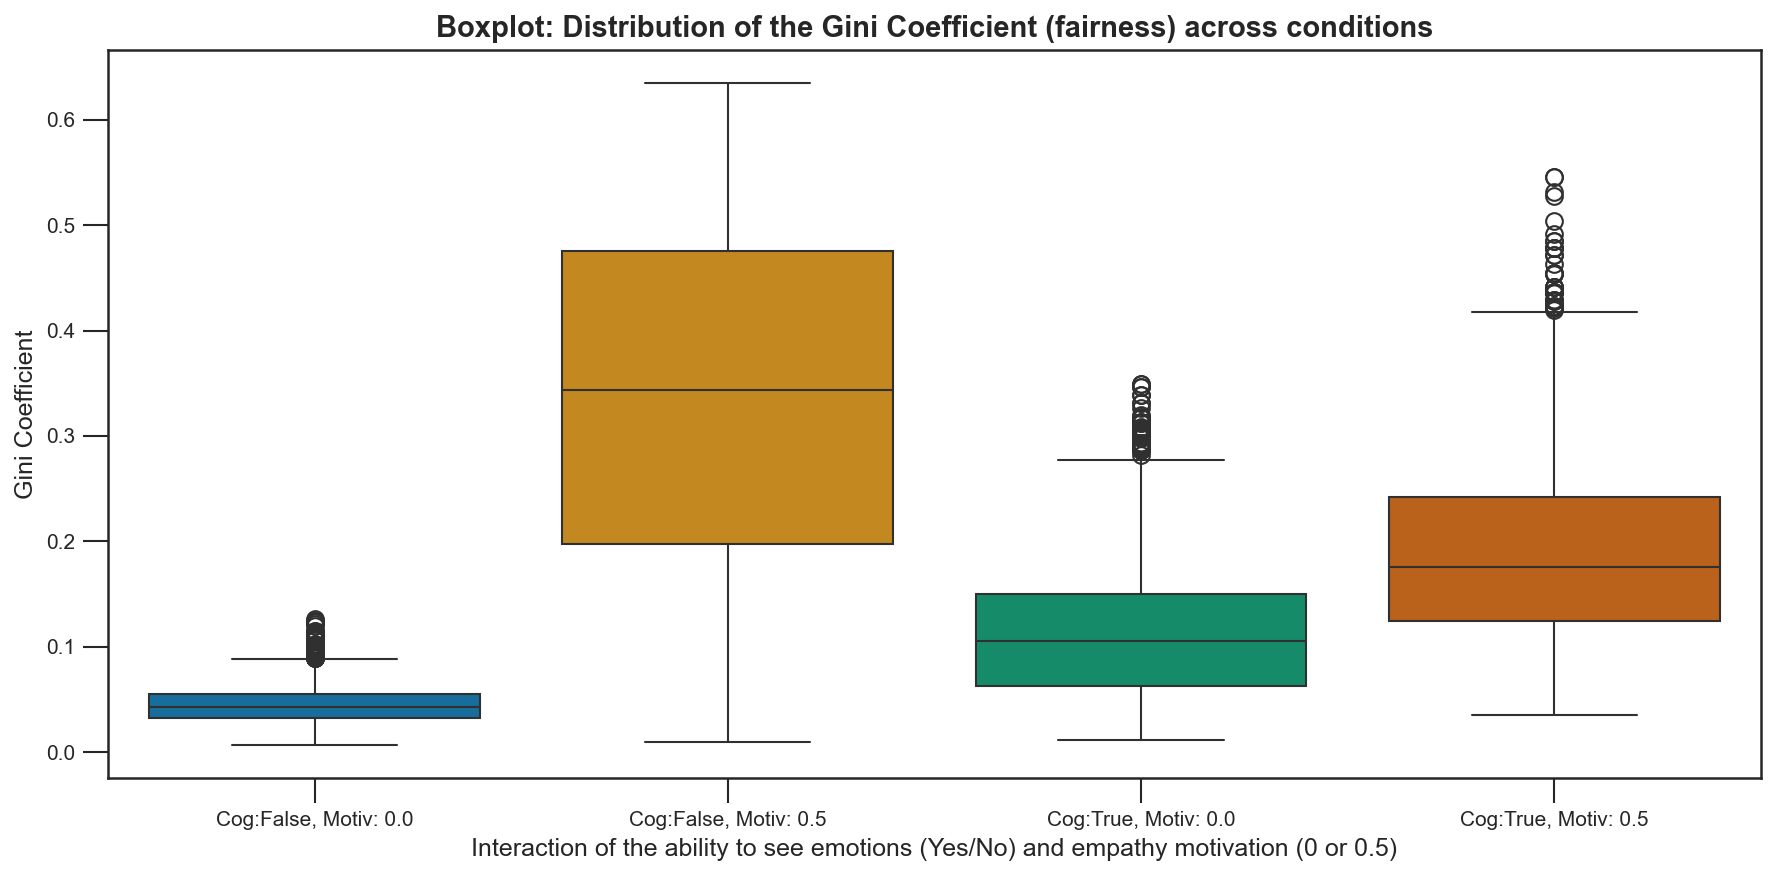

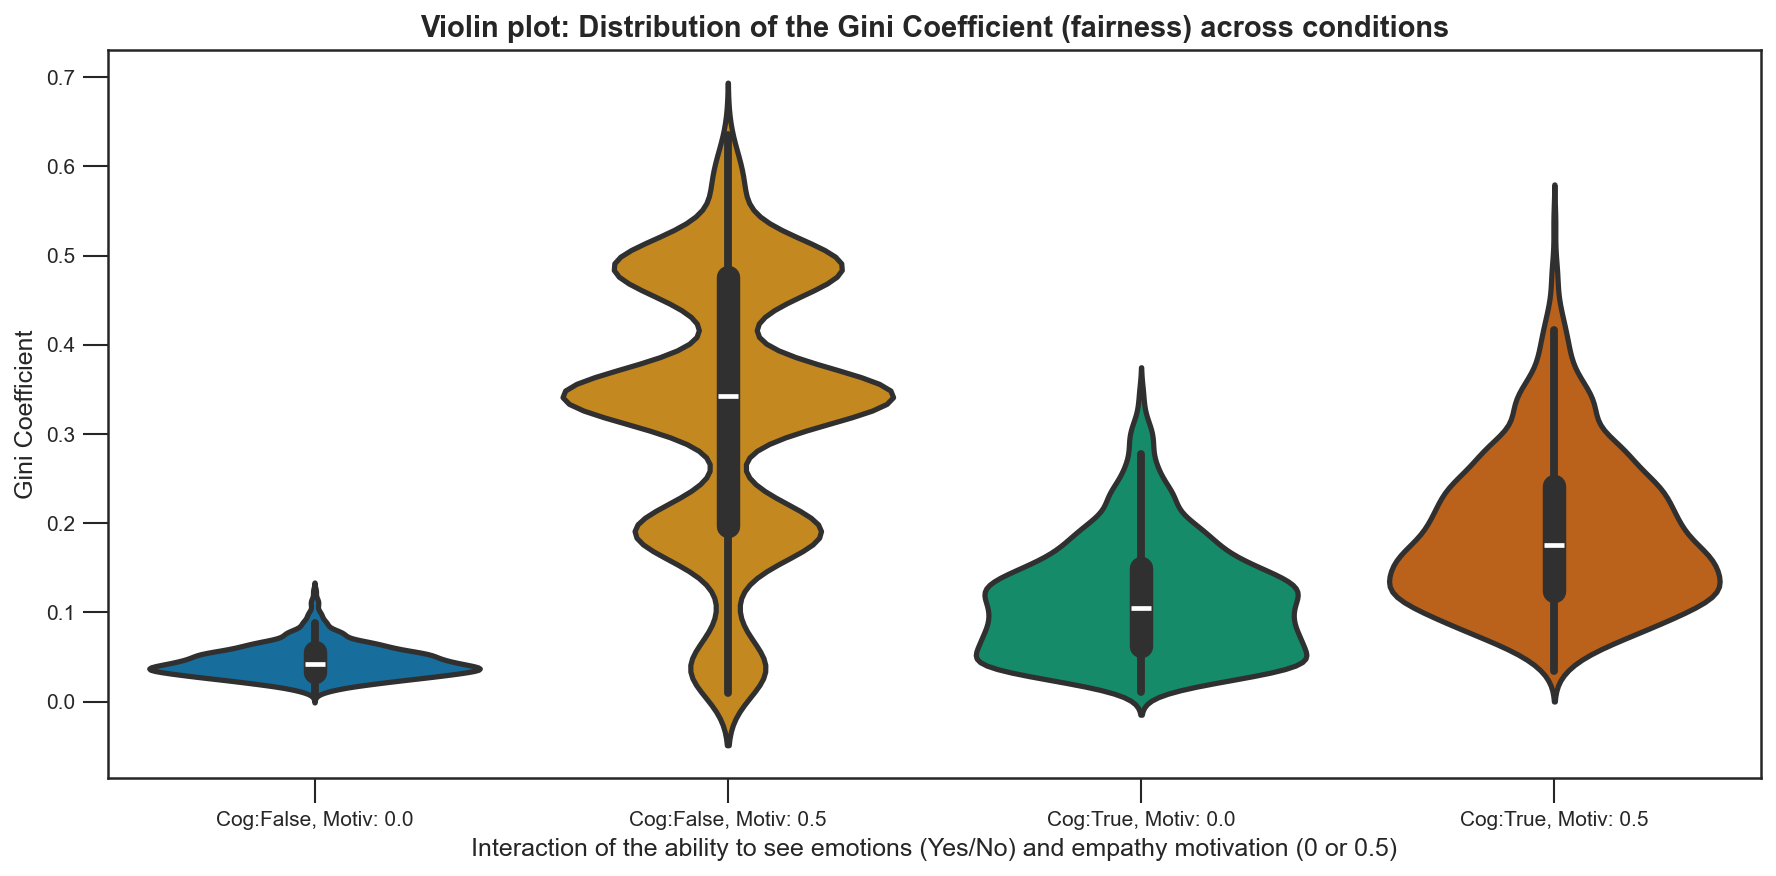

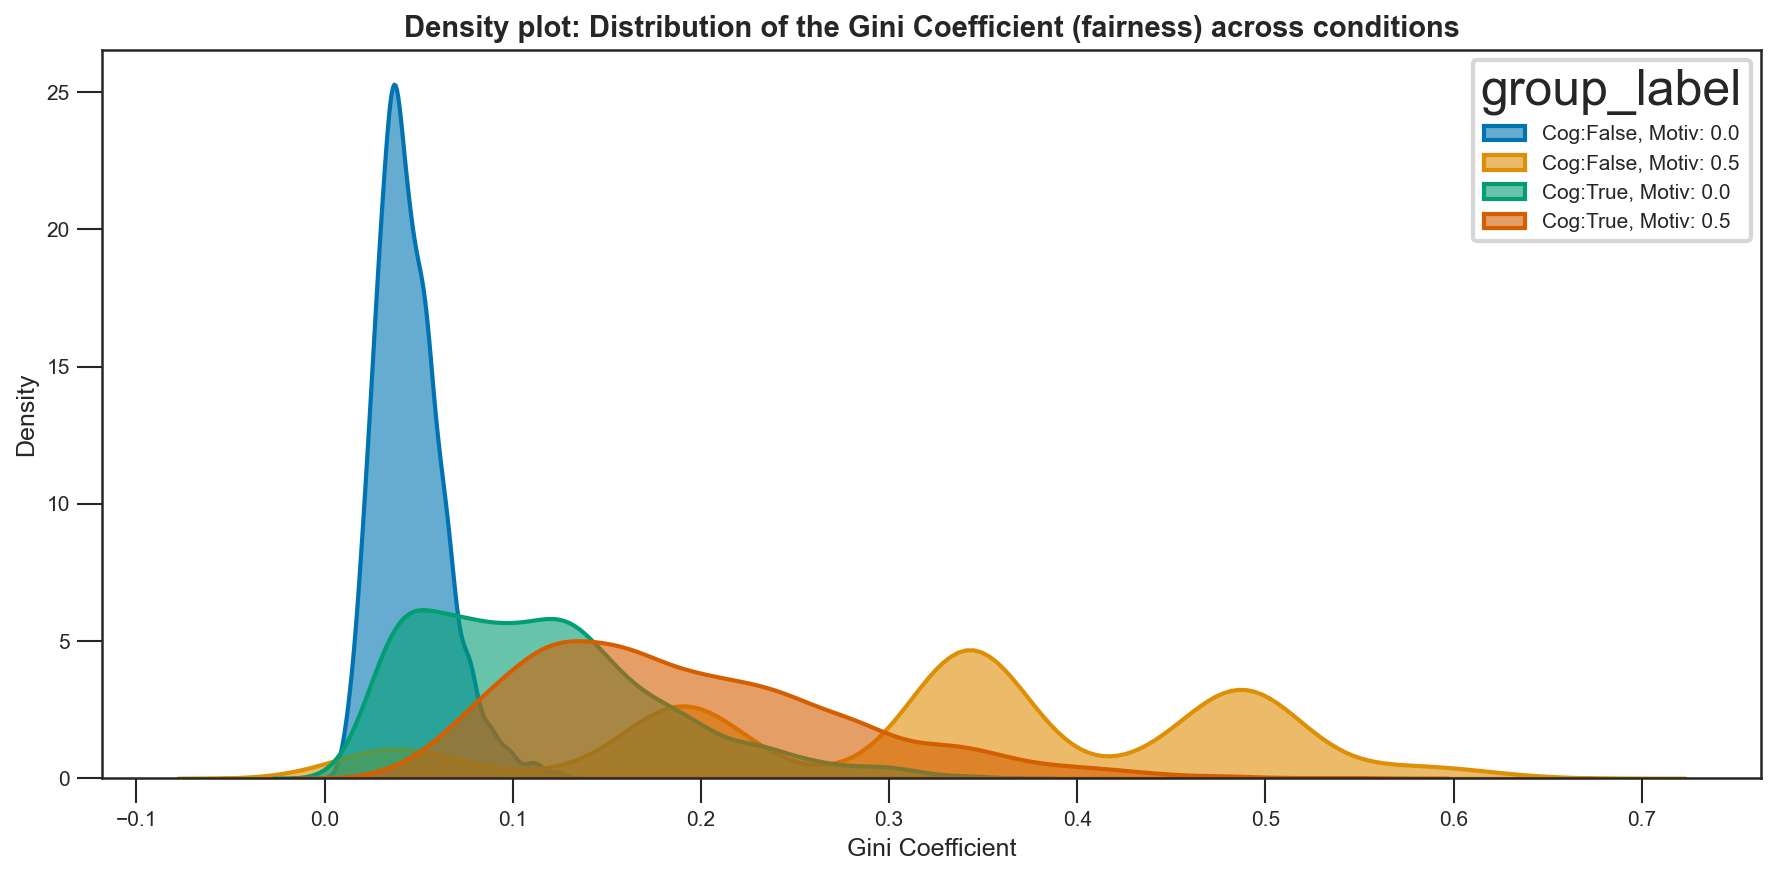

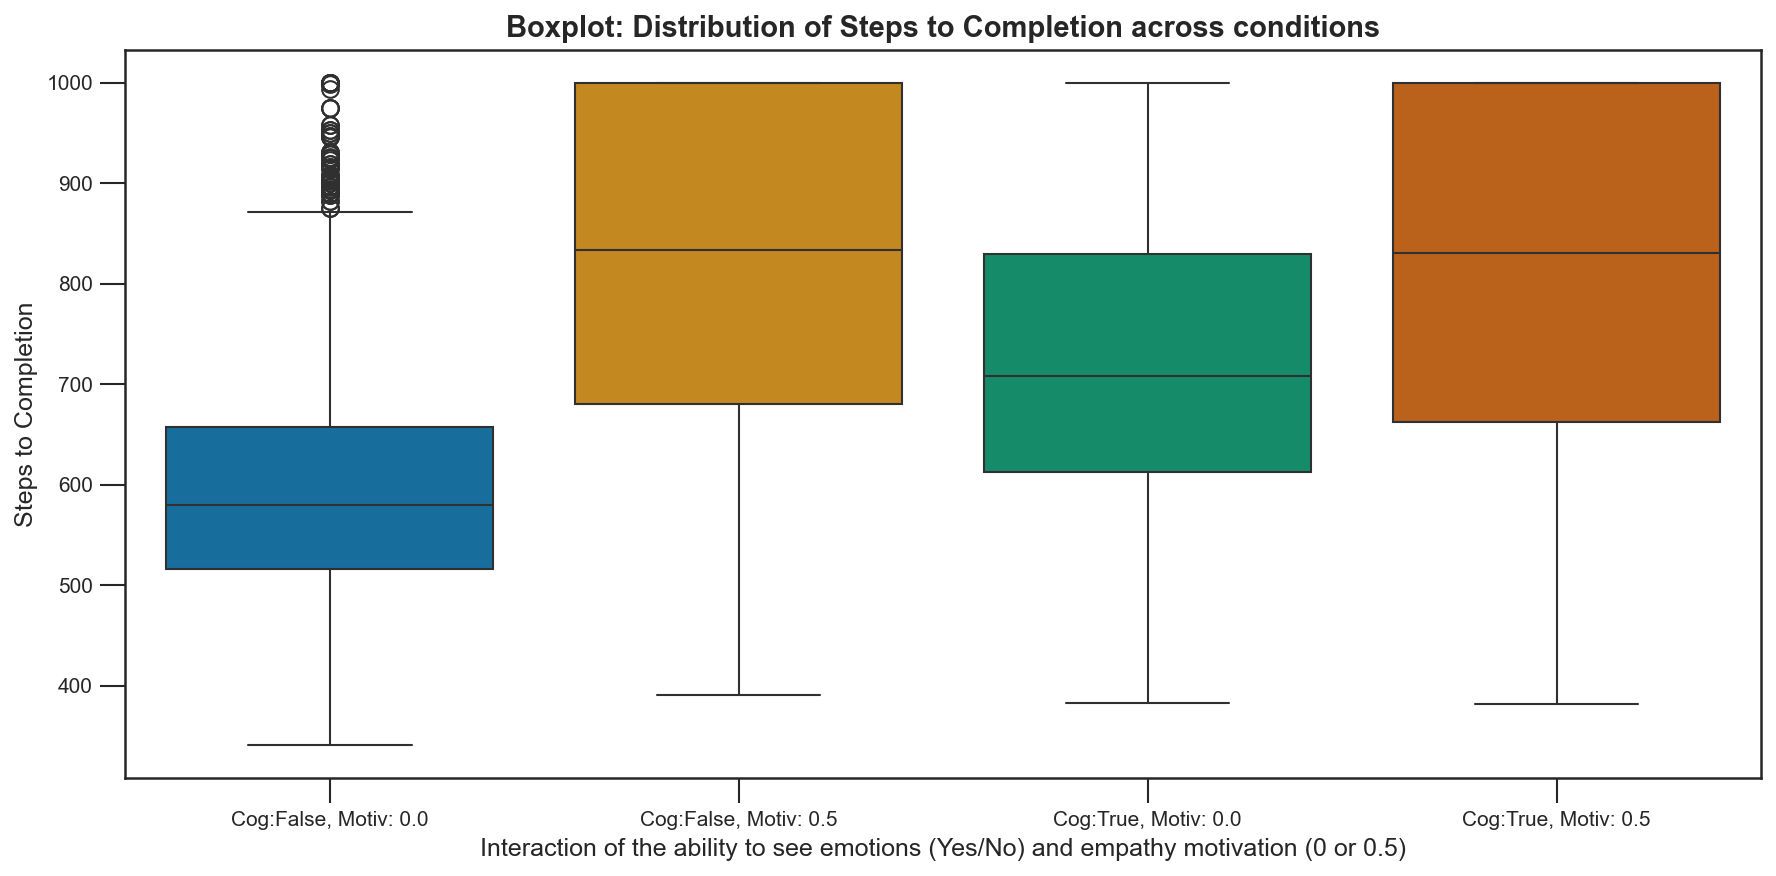

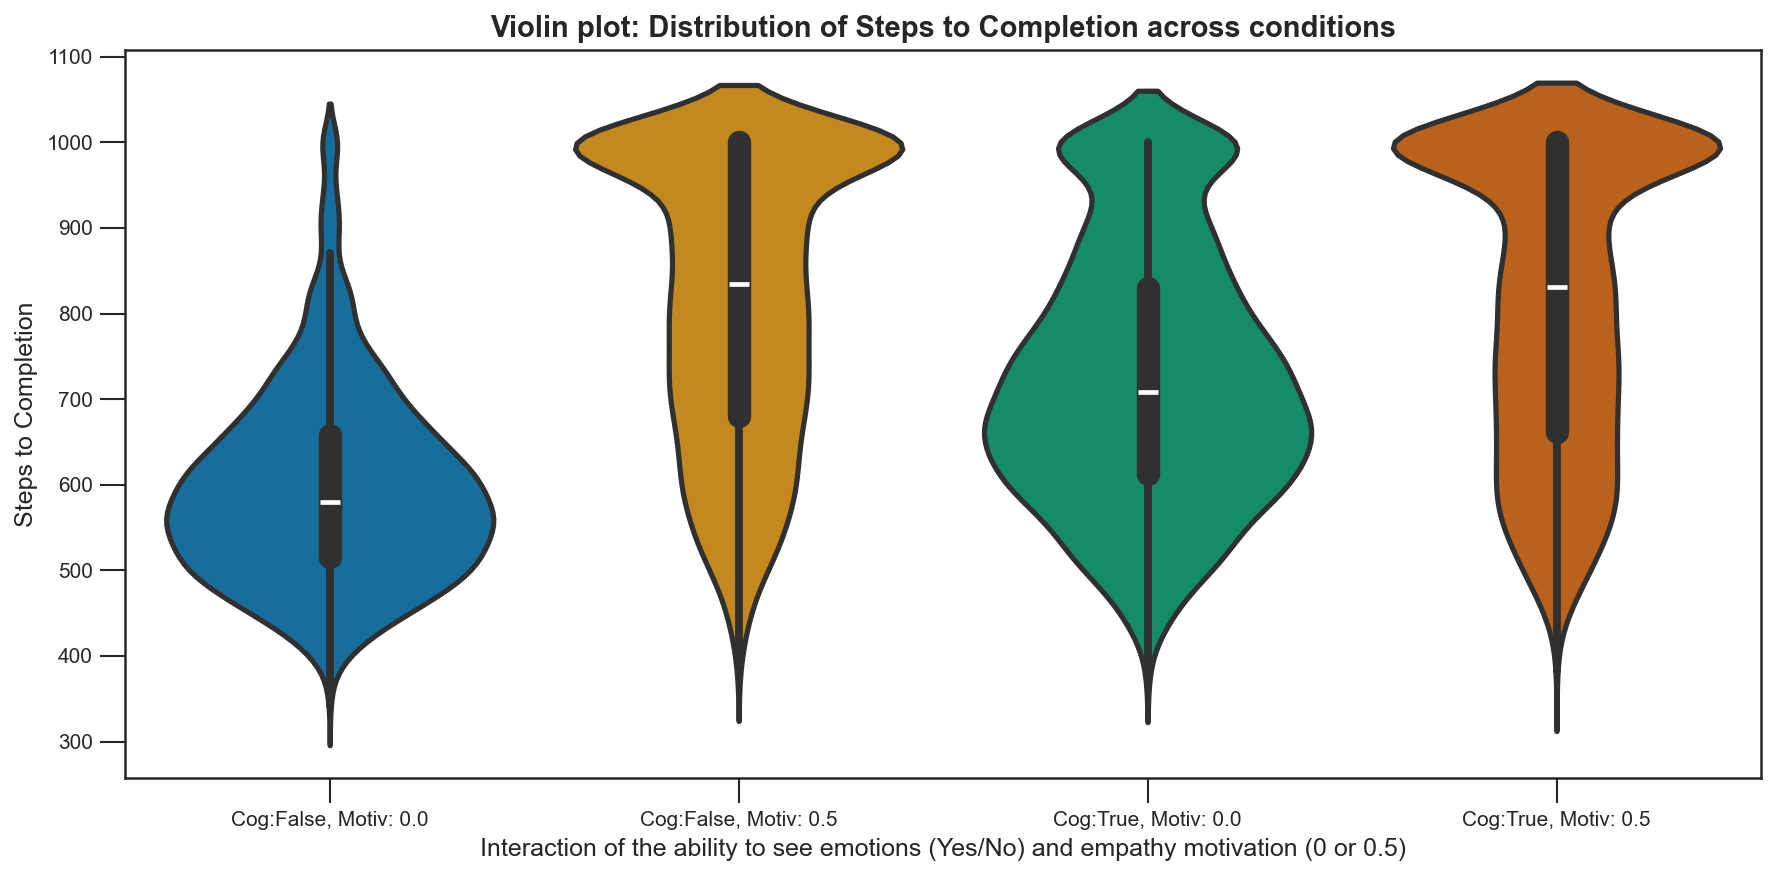

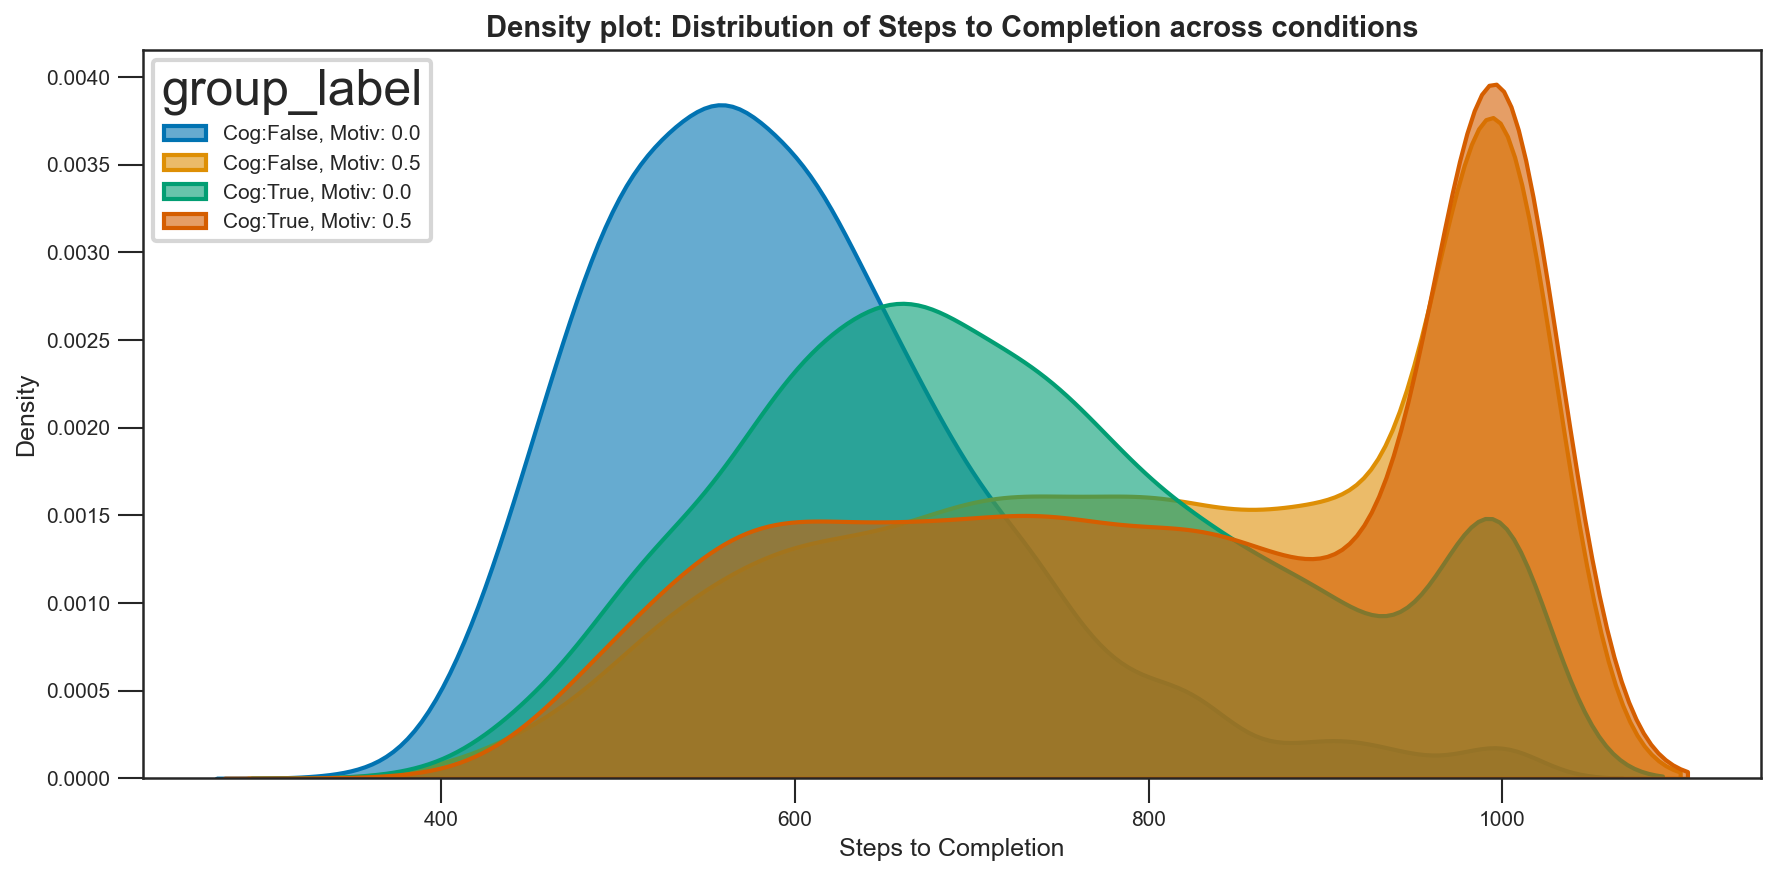

In [51]:
from visualisation_jerome import StyleConfig, MetricsVisualizer


seaborn_styles_list = ["darkgrid", "whitegrid", "dark", "white", "ticks"] 
seaborn_contexts_list = ["paper", "notebook", "talk", "poster"] 
seaborn_palettes_list = ["husl", "Set1", "Set2", "Set3", "Paired", "Dark2", "muted", "colorblind", "pastel"]


# Paramètres choisis
style = "ticks"
context = "poster"
palette = "colorblind"

# Créer la configuration et le visualizer
config = StyleConfig(style=style, context=context, palette=palette, figsize=(12,6), dpi=150)
viz = MetricsVisualizer(config=config)

# Variables à tracer
variables = ['gini_coef', 'steps_final']
hue = 'group_label'

# Labels et titres
labels_dict = {
    'gini_coef': {
        'title': "Distribution of the Gini Coefficient (fairness) across conditions",
        'ylabel': "Gini Coefficient",
        'xlabel': "Interaction of the ability to see emotions (Yes/No) and empathy motivation (0 or 0.5)"
    },
    'steps_final': {
        'title': "Distribution of Steps to Completion across conditions",
        'ylabel': "Steps to Completion",
        'xlabel': "Interaction of the ability to see emotions (Yes/No) and empathy motivation (0 or 0.5)"
    }
}

# Boucle sur les variables
for variable in variables:
    title = labels_dict[variable]['title']
    ylabel = labels_dict[variable]['ylabel']
    xlabel = labels_dict[variable]['xlabel']

    # ===== BOXPLOT =====
    fig_box = viz.boxplot(
        data=df_gt_summary,
        column=variable,
        hue=hue,
        title=f'Boxplot: {title}',
        ylabel=ylabel,
        xlabel=xlabel,
        hue_order=group_order
    )
    fig_box.show()

    # ===== VIOLIN PLOT =====
    fig_violin = viz.violinplot(
        data=df_gt_summary,
        column=variable,
        hue=hue,
        title=f'Violin plot: {title}',
        ylabel=ylabel,
        xlabel=xlabel,
        split=False,  # True seulement si exactement 2 catégories
        hue_order=group_order
    )
    fig_violin.show()

    # ===== DENSITY PLOT =====
    fig_density = viz.density_plot(
        data=df_gt_summary,
        column=variable,
        hue=hue,
        title=f'Density plot: {title}',
        xlabel=ylabel,
        alpha=0.6,
        fill=True,
        hue_order=group_order
    )
    fig_density.show()

# Fluctuation plots

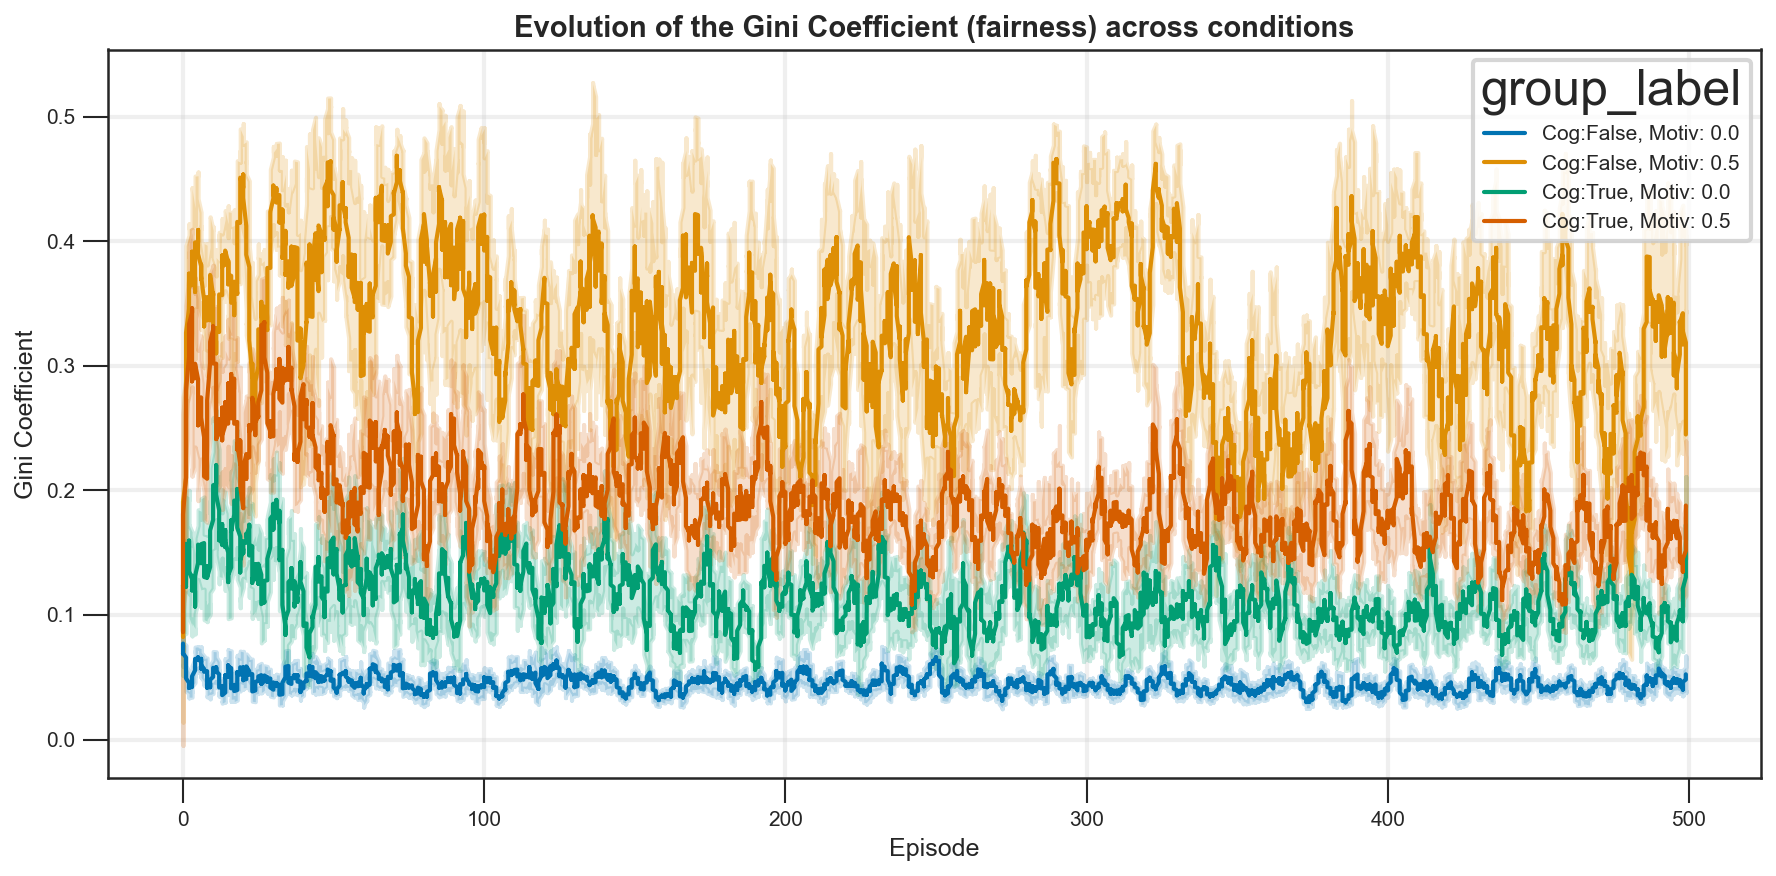

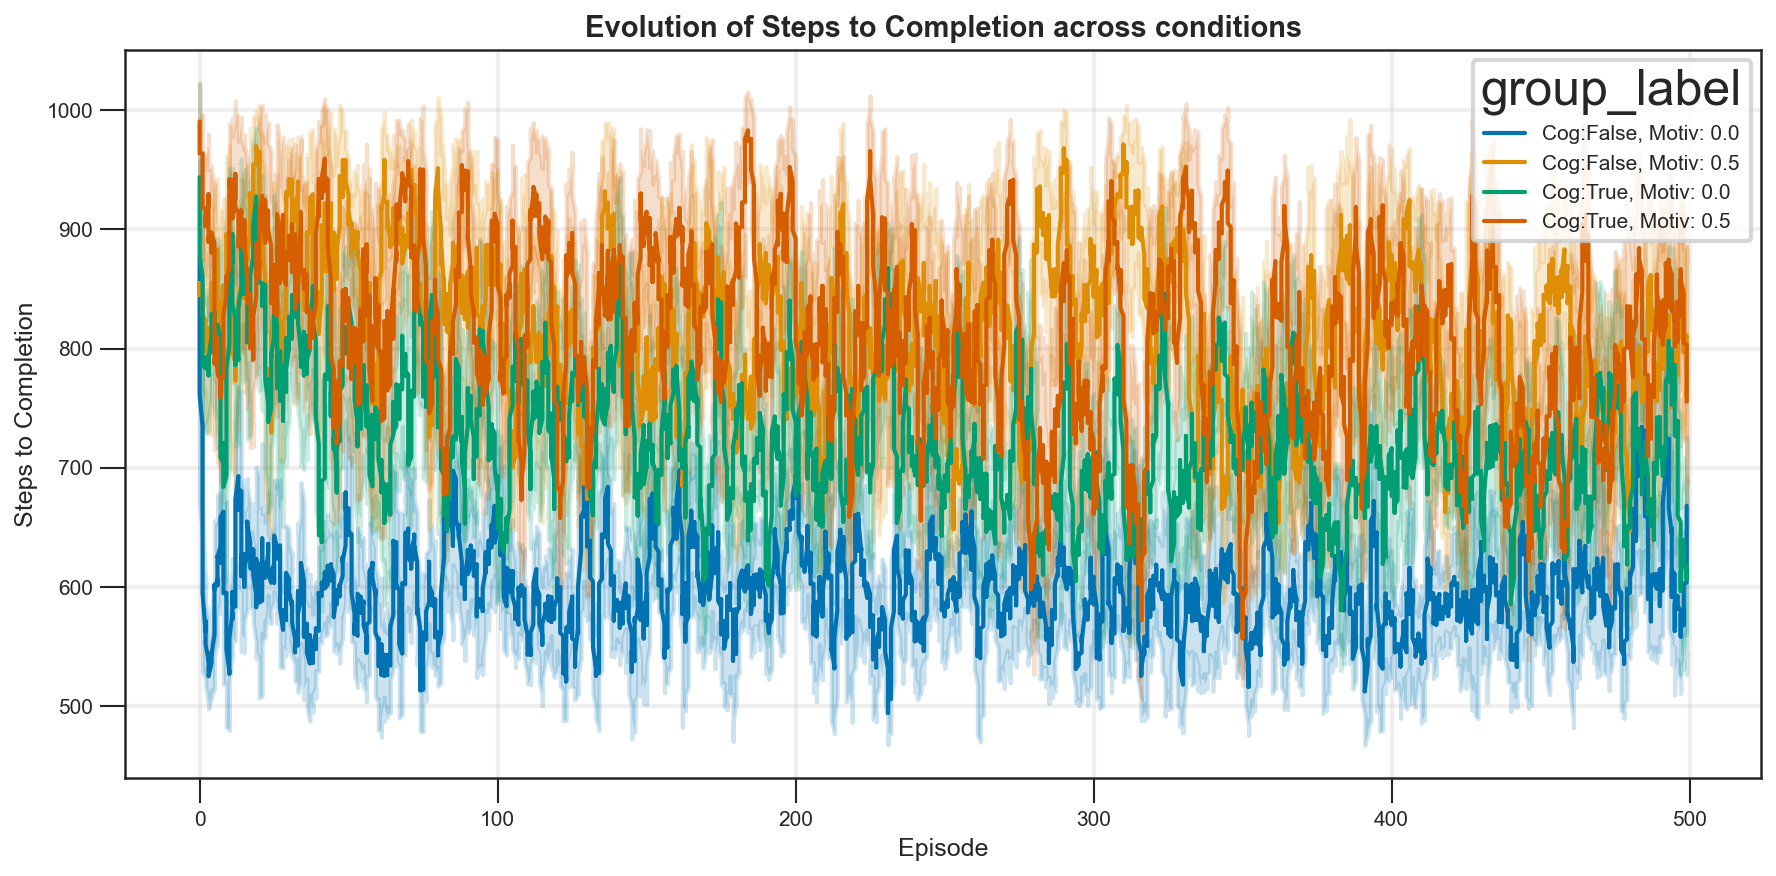

In [50]:
# =========================
# GINI — EVOLUTION
# =========================

fig_gini = viz.evolution_plot(
    data=df_gt_summary,
    x='episode',
    y='gini_coef',
    hue='group_label',
    hue_order=group_order,  # 👈 CRUCIAL
    
    title="Evolution of the Gini Coefficient (fairness) across conditions",
    xlabel="Episode",
    ylabel="Gini Coefficient",
    
    smooth=True,
    smoothing_window=15,
    smooth_method="uniform",
    
    confidence_interval=95,
    
    markers=False,
    figsize=(12, 6)  # 👈 même que ton config
)


# =========================
# STEPS — EVOLUTION
# =========================

fig_steps = viz.evolution_plot(
    data=df_gt_summary,
    x='episode',
    y='steps_final',
    hue='group_label',
    hue_order=group_order,  # 👈 CRUCIAL
    
    title="Evolution of Steps to Completion across conditions",
    xlabel="Episode",
    ylabel="Steps to Completion",
    
    smooth=True,
    smoothing_window=15,
    smooth_method="uniform",
    
    confidence_interval=95,
    
    markers=False,
    figsize=(12, 6)
)